# 03 · Real Regional Study — Valencia DANA 2024

This notebook migrates the real Valencia pilot study into the HYDRA notebook structure using `pyhydra` APIs.

Scope:
- Uses the validated daily precipitation matrices already stored in HYDRA.
- Rebuilds annual maxima for the local and general Valencia domains used in the original paper workflow.
- Recomputes point GEV, regional frequency analysis and hierarchical GEV analyses with `pyhydra`/PyMC.
- Loads the historical Stan/PyStan result tables only as archived benchmark outputs.

The aim is not to keep a Stan dependency alive: the reproducible HYDRA case study should run from the maintained Python/PyMC stack and use the archived Stan tables only to audit numerical differences.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import os
import sys

_cwd_import = Path.cwd()
_import_candidates = [Path('/workspace'), _cwd_import, *_cwd_import.parents]
_IMPORT_REPO_ROOT = next(
    (p for p in _import_candidates if (p / 'pyhydra').exists()),
    _cwd_import,
)
if str(_IMPORT_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_IMPORT_REPO_ROOT))
print('Using pyhydra from:', _IMPORT_REPO_ROOT / 'pyhydra')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyhydra.climate.spatial_analysis import (
    fit_gev_mle,
    fit_gev_lmom,
    fit_gev_bayes,
    return_level,
    return_level_bayes,
    regional_return_levels,
    regional_discordancy,
    regional_heterogeneity,
    HierarchicalGEV,
)

try:
    import pymc as pymc
    PYMC_AVAILABLE = True
    print(f'PyMC {pymc.__version__} available')
except ImportError:
    PYMC_AVAILABLE = False
    print('PyMC is not installed; Bayesian PyMC sections will be skipped.')


Using pyhydra from: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/pyhydra
PyMC 6.0.1 available


In [2]:
# Portable repo-root / data-dir resolution (local clone, Docker, Azure ML)
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
CASE_DIR = DATA_DIR / 'pilot_cases' / 'valencia_dana'
STAN_REF_DIR = CASE_DIR / 'stan_reference'

DAILY_CSV = CASE_DIR / 'Daily_series_conjuntas_V2.csv'
STATIONS_CSV = CASE_DIR / 'Estaciones_Conjuntas_V2.csv'
LEGACY_DAILY_CSV = CASE_DIR / 'Daily_series_conjuntas_legacy.csv'
LEGACY_STATIONS_CSV = CASE_DIR / 'Estaciones_Conjuntas_legacy.csv'

RUN_PYMC_POINT = os.environ.get('HYDRA_RUN_PYMC_POINT', '1') == '1'
RUN_PYMC_RFA = os.environ.get('HYDRA_RUN_PYMC_RFA', '1') == '1'
RUN_PYMC_HIER_LOCAL = os.environ.get('HYDRA_RUN_PYMC_HIER_LOCAL', '0') == '1'
RUN_PYMC_HIER_GENERAL = os.environ.get('HYDRA_RUN_PYMC_HIER_GENERAL', '0') == '1'
PYMC_CHAINS = int(os.environ.get('HYDRA_PYMC_CHAINS', '2'))
PYMC_DRAWS = int(os.environ.get('HYDRA_PYMC_DRAWS', '80'))
PYMC_WARMUP = int(os.environ.get('HYDRA_PYMC_WARMUP', '80'))
PYMC_ADAPT_DELTA = float(os.environ.get('HYDRA_PYMC_ADAPT_DELTA', '0.99'))
PYMC_SEED = int(os.environ.get('HYDRA_PYMC_SEED', '42'))
PYMC_PROGRESS = os.environ.get('HYDRA_PYMC_PROGRESS', '0') == '1'

print('CASE_DIR:', CASE_DIR)
print('Daily data:', DAILY_CSV.exists(), DAILY_CSV)
print('Station metadata:', STATIONS_CSV.exists(), STATIONS_CSV)
print('Stan reference:', STAN_REF_DIR.exists(), STAN_REF_DIR)
print('Legacy daily data:', LEGACY_DAILY_CSV.exists(), LEGACY_DAILY_CSV)
print('PyMC config:', {
    'point': RUN_PYMC_POINT,
    'rfa': RUN_PYMC_RFA,
    'hier_local': RUN_PYMC_HIER_LOCAL,
    'hier_general': RUN_PYMC_HIER_GENERAL,
    'chains': PYMC_CHAINS,
    'draws': PYMC_DRAWS,
    'warmup': PYMC_WARMUP,
})


CASE_DIR: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana
Daily data: True /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana/Daily_series_conjuntas_V2.csv
Station metadata: True /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana/Estaciones_Conjuntas_V2.csv
Stan reference: True /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana/stan_reference
Legacy daily data: True /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana/Daily_series_conjuntas_legacy.csv
PyMC config: {'point': True, 'rfa': True, 'hier_local': False, 'hier_general': False, 'chains': 2, 'draws': 80, 'warmup': 80}


---
## 1. Load daily precipitation and station metadata

The base daily and metadata CSV files are identical to the `Valencia-Study` source files. They are not duplicated here; HYDRA keeps one canonical copy under `data/pilot_cases/valencia_dana/`.


In [3]:
daily = pd.read_csv(DAILY_CSV, parse_dates=['Unnamed: 0']).rename(columns={'Unnamed: 0': 'date'})
daily = daily.set_index('date').sort_index()
stations_meta = pd.read_csv(STATIONS_CSV).rename(columns={'Unnamed: 0': 'station'})
stations_meta = stations_meta.set_index('station')

# Legacy matrix from the original Valencia-Study repository. It contains a few
# AEMET stations used by the archived Stan regional tables but not present in V2.
legacy_daily = None
if LEGACY_DAILY_CSV.exists():
    legacy_daily = pd.read_csv(LEGACY_DAILY_CSV, parse_dates=['Unnamed: 0']).rename(columns={'Unnamed: 0': 'date'})
    legacy_daily = legacy_daily.set_index('date').sort_index()
    # Prefer V2 where both matrices contain the same station; add legacy-only columns.
    legacy_only = [c for c in legacy_daily.columns if c not in daily.columns]
    daily_region = daily.join(legacy_daily[legacy_only], how='outer')
else:
    legacy_only = []
    daily_region = daily

print(f'Daily V2 matrix: {daily.shape[0]:,} days × {daily.shape[1]:,} stations')
print(f'Period: {daily.index.min().date()} → {daily.index.max().date()}')
print(f'Station metadata: {stations_meta.shape[0]:,} stations')
print(f'Legacy-only columns available for regional replication: {len(legacy_only)}')


Daily V2 matrix: 38,331 days × 224 stations
Period: 1920-01-01 → 2024-12-10
Station metadata: 224 stations
Legacy-only columns available for regional replication: 60


---
## 2. Rebuild annual maxima

The paper study uses two event definitions:
- **Without DANA**: annual maxima up to 2023, excluding the October 2024 DANA event.
- **With DANA**: same series plus the 2024 annual maximum, where available.


In [4]:
def annual_maxima_from_daily(df, stations, start=None):
    missing = [s for s in stations if s not in df.columns]
    if missing:
        raise KeyError(f'Missing stations in daily matrix: {missing}')
    data = df[stations]
    if start is not None:
        data = data.loc[str(start):]
    out = data.resample('YE').max(min_count=1).replace(0.0, np.nan)
    out.index = out.index.year
    out.index.name = 'Year'
    return out

stan_regional_small_seed = pd.read_csv(STAN_REF_DIR / 'resultados_regional_pequeno.csv')
regional_small_stan = sorted(stan_regional_small_seed['Station'].astype(str).unique())
regional_small = [s for s in regional_small_stan if s in daily_region.columns]
regional_missing = [s for s in regional_small_stan if s not in daily_region.columns]

# Local hierarchical domain from the original Valencia notebook
# Gev_hicherical_Pequeño.ipynb: legacy matrix, start year 2000, 10 stations.
hierarchical_local_original = [
    '8337X', '8309X', '8414A', '8416X', 'V05', 'V17', 'V01',
    'c18m111e01', 'c16m244e01', 'V103',
]
hierarchical_local = [s for s in hierarchical_local_original if s in daily_region.columns]

# General hierarchical domain from Gev_hicherical_Grande.ipynb: all V2 columns from 2000.
hierarchical_general = list(daily.columns)
core_stations = ['8337X', 'V103']
T_VALUES = [10, 100, 500]

ams_all = annual_maxima_from_daily(daily_region, regional_small)
ams_without_dana = ams_all.loc[ams_all.index <= 2023]
ams_with_dana = ams_all.loc[ams_all.index <= 2024]

ams_hier_local = annual_maxima_from_daily(daily_region, hierarchical_local, start=2000)
ams_hier_local_without_dana = ams_hier_local.loc[ams_hier_local.index <= 2023]
ams_hier_local_with_dana = ams_hier_local.loc[ams_hier_local.index <= 2024]

ams_hier_general = annual_maxima_from_daily(daily, hierarchical_general, start=2000)
ams_hier_general_without_dana = ams_hier_general.loc[ams_hier_general.index <= 2023]
ams_hier_general_with_dana = ams_hier_general.loc[ams_hier_general.index <= 2024]

print('Regional stations from Stan small RFA table:', regional_small_stan)
print('Regional stations available in HYDRA:', regional_small)
print('Missing regional stations:', regional_missing if regional_missing else 'none')
print('Local hierarchical domain:', len(hierarchical_local), hierarchical_local)
print('General hierarchical domain:', len(hierarchical_general), 'stations')
print('AMS small RFA without DANA:', ams_without_dana.shape, f'{ams_without_dana.index.min()}-{ams_without_dana.index.max()}')
print('AMS small RFA with DANA   :', ams_with_dana.shape, f'{ams_with_dana.index.min()}-{ams_with_dana.index.max()}')
print('AMS local hierarchical    :', ams_hier_local.shape)
print('AMS general hierarchical  :', ams_hier_general.shape)
print()
print('2024 maxima at core stations:')
print(ams_with_dana.loc[[2024], core_stations].T.to_string(header=False))


Regional stations from Stan small RFA table: ['8309X', '8337X', '8414A', '8416X', 'V01', 'V05', 'V103', 'V17', 'c16m244e01', 'c18m109e01', 'c18m111e01']
Regional stations available in HYDRA: ['8309X', '8337X', '8414A', '8416X', 'V01', 'V05', 'V103', 'V17', 'c16m244e01', 'c18m109e01', 'c18m111e01']
Missing regional stations: none
Local hierarchical domain: 10 ['8337X', '8309X', '8414A', '8416X', 'V05', 'V17', 'V01', 'c18m111e01', 'c16m244e01', 'V103']
General hierarchical domain: 224 stations
AMS small RFA without DANA: (104, 11) 1920-2023
AMS small RFA with DANA   : (105, 11) 1920-2024
AMS local hierarchical    : (25, 10)
AMS general hierarchical  : (25, 224)

2024 maxima at core stations:
8337X  710.8
V103   265.1


---
## 3. Exploratory figures from the real Valencia data

These figures reproduce the exploratory layer of the original Valencia notebooks: station location, annual maxima by station, event contrast and regional standardised series.


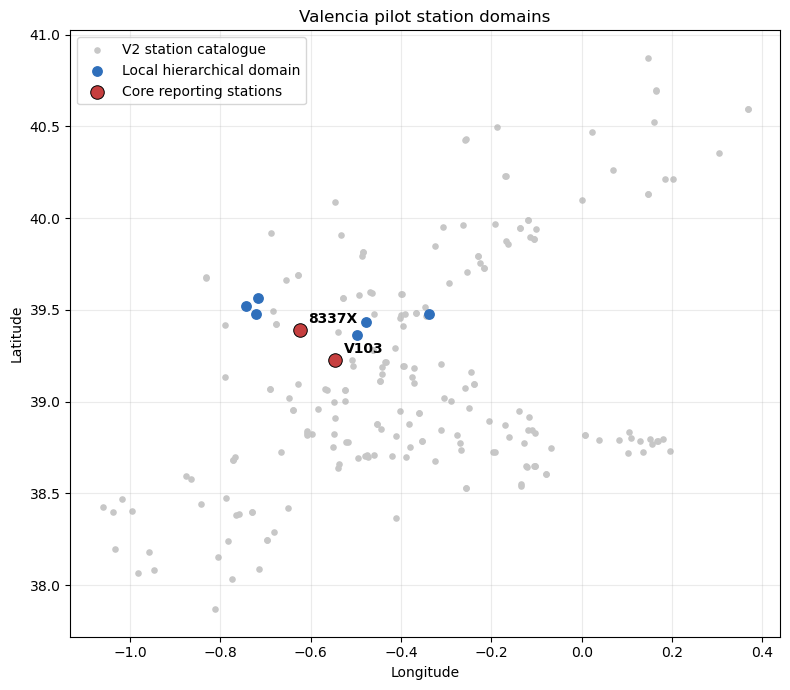

In [5]:
# Station location map without external GIS/WMS dependencies.
fig, ax = plt.subplots(figsize=(8, 7))
meta_all = stations_meta.dropna(subset=['Longitud', 'Latitud']).copy()
ax.scatter(meta_all['Longitud'], meta_all['Latitud'], s=14, color='0.78', label='V2 station catalogue', zorder=1)

local_meta = stations_meta.reindex([s for s in hierarchical_local if s in stations_meta.index]).dropna(subset=['Longitud', 'Latitud'])
ax.scatter(local_meta['Longitud'], local_meta['Latitud'], s=46, color='#2f6fbb', label='Local hierarchical domain', zorder=2)

core_meta = stations_meta.reindex([s for s in core_stations if s in stations_meta.index]).dropna(subset=['Longitud', 'Latitud'])
ax.scatter(core_meta['Longitud'], core_meta['Latitud'], s=95, color='#c63f3f', edgecolor='black', linewidth=0.7, label='Core reporting stations', zorder=3)
for station, row in core_meta.iterrows():
    ax.annotate(station, (row['Longitud'], row['Latitud']), xytext=(6, 5), textcoords='offset points', fontsize=10, weight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Valencia pilot station domains')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


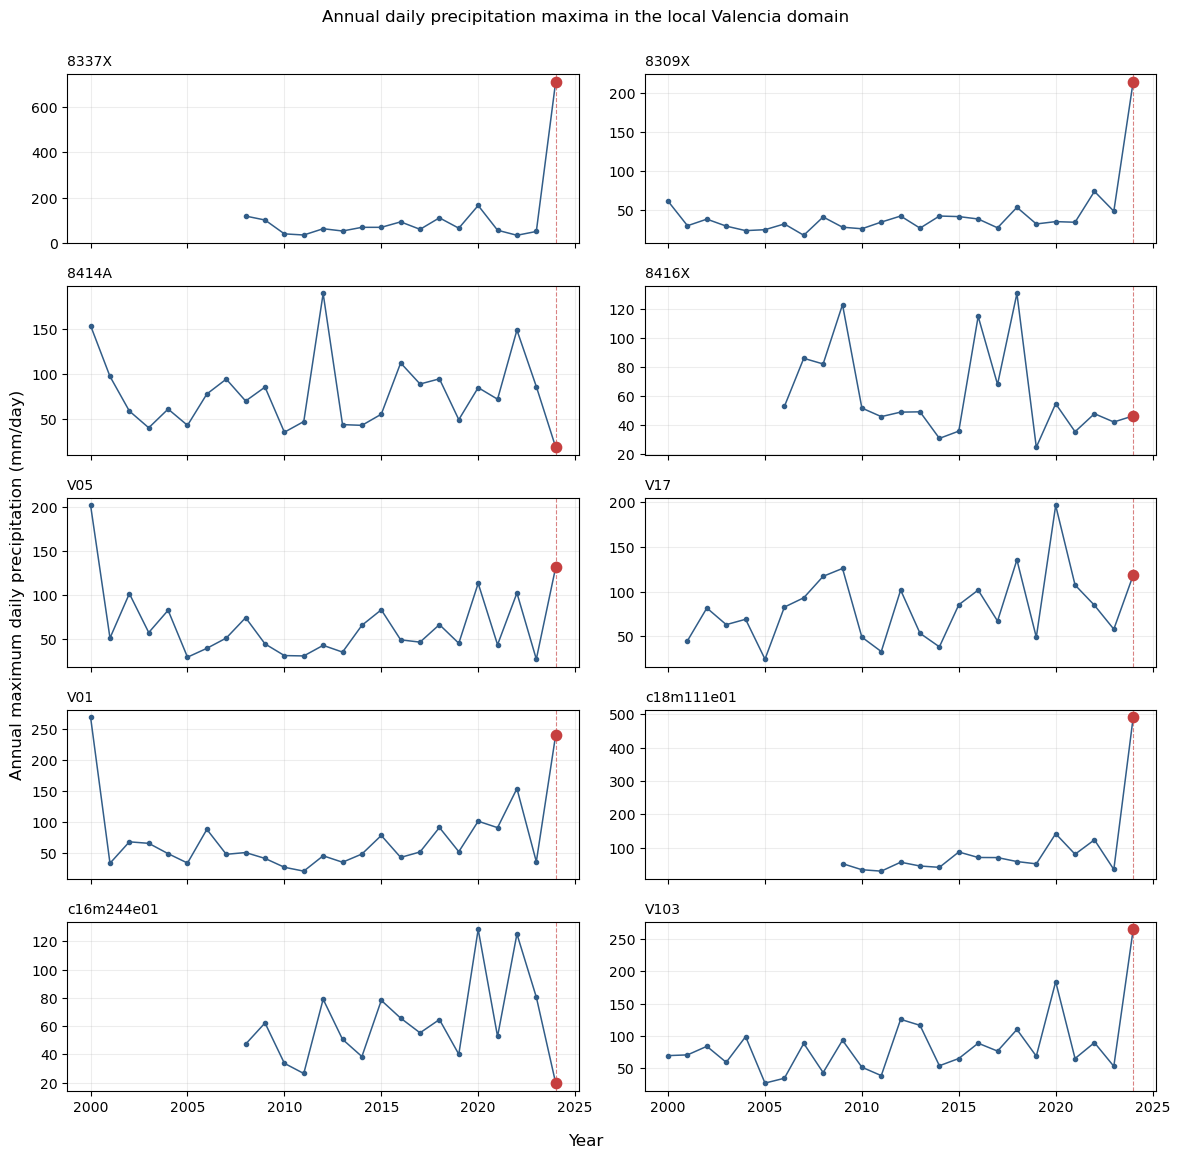

In [6]:
plot_stations = hierarchical_local
n_cols = 2
n_rows = int(np.ceil(len(plot_stations) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.3 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, station in zip(axes, plot_stations):
    series = ams_hier_local_with_dana[station].dropna()
    ax.plot(series.index, series.values, marker='o', markersize=3, linewidth=1.1, color='#325d88')
    if 2024 in series.index:
        ax.scatter([2024], [series.loc[2024]], s=55, color='#c63f3f', zorder=3)
    ax.axvline(2024, color='#c63f3f', linestyle='--', linewidth=0.8, alpha=0.65)
    ax.set_title(station, loc='left', fontsize=10)
    ax.grid(True, alpha=0.22)
for ax in axes[len(plot_stations):]:
    ax.axis('off')
fig.suptitle('Annual daily precipitation maxima in the local Valencia domain', y=1.0)
fig.supxlabel('Year')
fig.supylabel('Annual maximum daily precipitation (mm/day)')
plt.tight_layout()
plt.show()


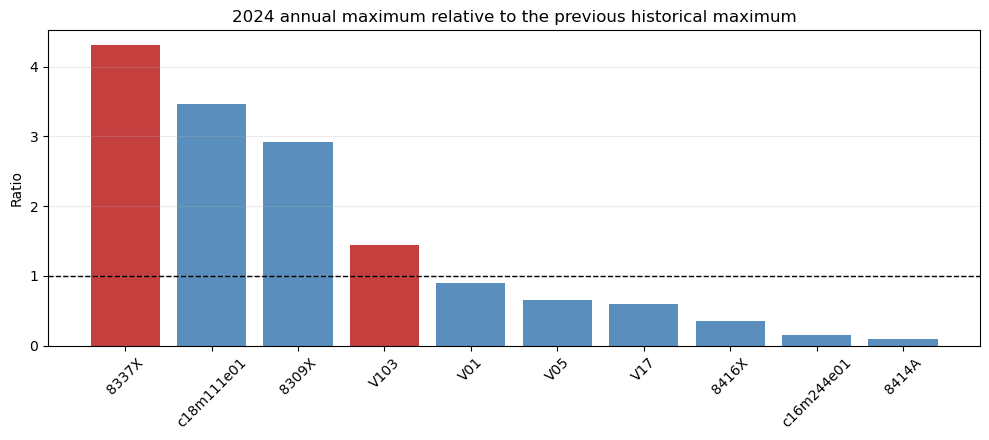

,Without DANA max,2024 maximum,2024 / previous maximum
8337X,165.00,710.80,4.31
c18m111e01,141.60,491.00,3.47
8309X,73.60,215.20,2.92
V103,183.90,265.10,1.44
V01,268.00,239.92,0.90
V05,201.40,131.53,0.65
V17,196.22,118.28,0.60
8416X,130.40,46.00,0.35
c16m244e01,128.50,19.60,0.15
8414A,188.90,18.90,0.10


In [7]:
event_summary = pd.DataFrame({
    'Without DANA max': ams_hier_local_without_dana.max(axis=0),
    '2024 maximum': ams_hier_local_with_dana.loc[2024],
}).dropna()
event_summary['2024 / previous maximum'] = event_summary['2024 maximum'] / event_summary['Without DANA max']
event_summary = event_summary.sort_values('2024 / previous maximum', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#c63f3f' if s in core_stations else '#5a8fbd' for s in event_summary.index]
ax.bar(event_summary.index, event_summary['2024 / previous maximum'], color=colors)
ax.axhline(1.0, color='black', linewidth=1, linestyle='--')
ax.set_ylabel('Ratio')
ax.set_title('2024 annual maximum relative to the previous historical maximum')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

event_summary.round(2)


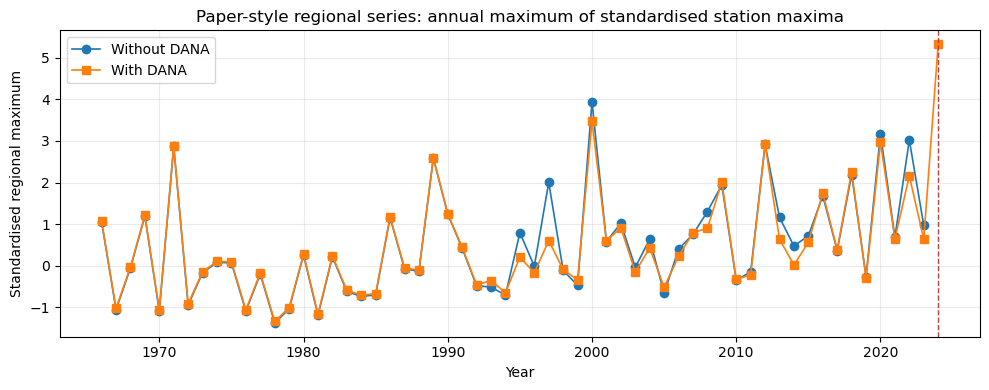

In [8]:
def standardised_regional_series_for_plot(ams):
    means = ams.mean(axis=0, skipna=True)
    scales = pd.Series(np.nanstd(ams.values, axis=0, ddof=0), index=ams.columns).replace(0.0, np.nan)
    standardised = (ams - means) / scales
    regional = standardised.max(axis=1, skipna=True).dropna()
    return regional

regional_series_without = standardised_regional_series_for_plot(ams_without_dana)
regional_series_with = standardised_regional_series_for_plot(ams_with_dana)
regional_index_without = regional_series_without.index
regional_index_with = regional_series_with.index

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(regional_index_without, regional_series_without, marker='o', linewidth=1.2, label='Without DANA')
ax.plot(regional_index_with, regional_series_with, marker='s', linewidth=1.2, label='With DANA')
ax.axvline(2024, color='#c63f3f', linestyle='--', linewidth=1)
ax.set_title('Paper-style regional series: annual maximum of standardised station maxima')
ax.set_xlabel('Year')
ax.set_ylabel('Standardised regional maximum')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


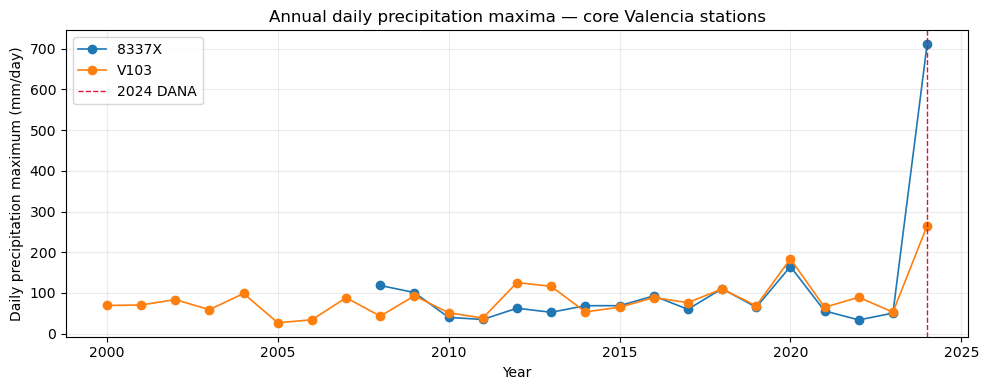

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for station in core_stations:
    ax.plot(ams_with_dana.index, ams_with_dana[station], marker='o', linewidth=1.2, label=station)
ax.axvline(2024, color='crimson', linestyle='--', linewidth=1, label='2024 DANA')
ax.set_title('Annual daily precipitation maxima — core Valencia stations')
ax.set_ylabel('Daily precipitation maximum (mm/day)')
ax.set_xlabel('Year')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


---
### Coverage, dependence and empirical distribution diagnostics

These checks complete the exploratory layer: record completeness, dependence between stations, empirical annual maxima distributions and spatial footprint of the 2024 maximum.


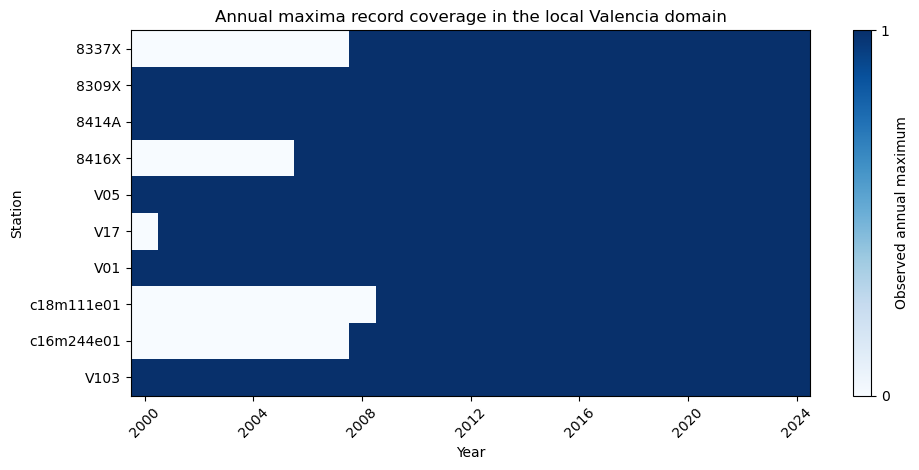

,first_year,last_year,n_years,missing_years
c18m111e01,2009,2024,16,9
8337X,2008,2024,17,8
c16m244e01,2008,2024,17,8
8416X,2006,2024,19,6
V17,2001,2024,24,1
8309X,2000,2024,25,0
8414A,2000,2024,25,0
V05,2000,2024,25,0
V01,2000,2024,25,0
V103,2000,2024,25,0


In [10]:
coverage = ams_hier_local_with_dana.notna().astype(int)
fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(coverage.T, aspect='auto', interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
ax.set_yticks(range(len(coverage.columns)))
ax.set_yticklabels(coverage.columns)
ax.set_xticks(range(0, len(coverage.index), 4))
ax.set_xticklabels(coverage.index[::4], rotation=45)
ax.set_title('Annual maxima record coverage in the local Valencia domain')
ax.set_xlabel('Year')
ax.set_ylabel('Station')
fig.colorbar(im, ax=ax, ticks=[0, 1], label='Observed annual maximum')
plt.tight_layout()
plt.show()

coverage_summary = pd.DataFrame({
    'first_year': ams_hier_local_with_dana.apply(lambda s: s.dropna().index.min()),
    'last_year': ams_hier_local_with_dana.apply(lambda s: s.dropna().index.max()),
    'n_years': ams_hier_local_with_dana.count(),
    'missing_years': ams_hier_local_with_dana.isna().sum(),
}).sort_values('n_years')
coverage_summary


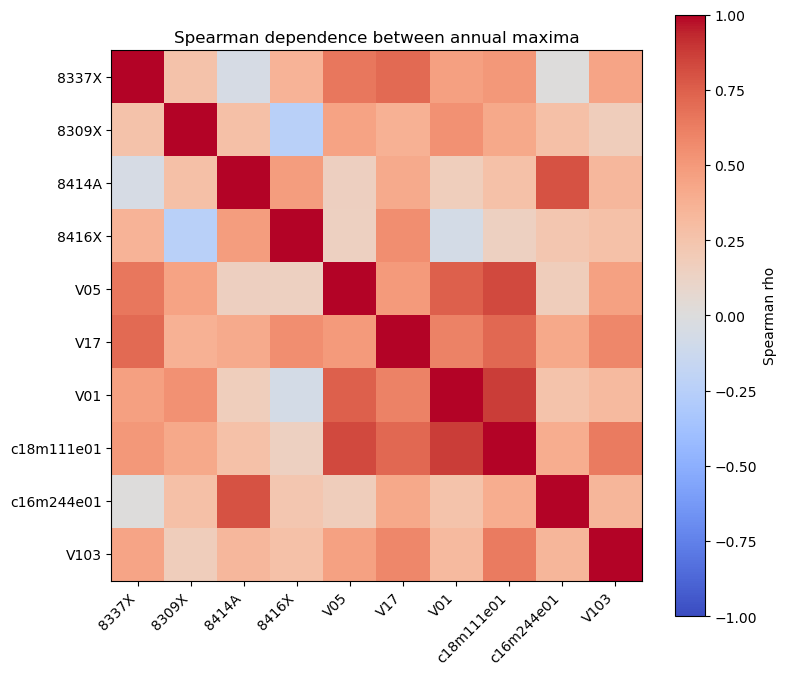

In [11]:
corr = ams_hier_local_with_dana.corr(method='spearman', min_periods=8)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Spearman dependence between annual maxima')
fig.colorbar(im, ax=ax, label='Spearman rho')
plt.tight_layout()
plt.show()


/var/folders/44/dw7p6q9108xcc4mmh_f7q1vc0000gn/T/ipykernel_87984/596935529.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=hierarchical_local, showfliers=True, patch_artist=True,


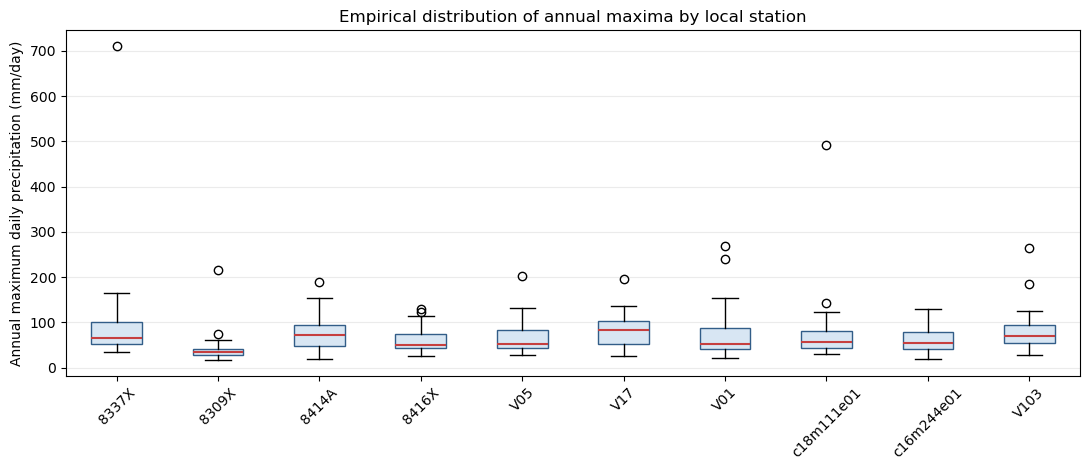

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.8))
box_data = [ams_hier_local_with_dana[s].dropna().values for s in hierarchical_local]
ax.boxplot(box_data, labels=hierarchical_local, showfliers=True, patch_artist=True,
           boxprops={'facecolor': '#d8e6f3', 'edgecolor': '#325d88'},
           medianprops={'color': '#c63f3f', 'linewidth': 1.5})
ax.set_ylabel('Annual maximum daily precipitation (mm/day)')
ax.set_title('Empirical distribution of annual maxima by local station')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


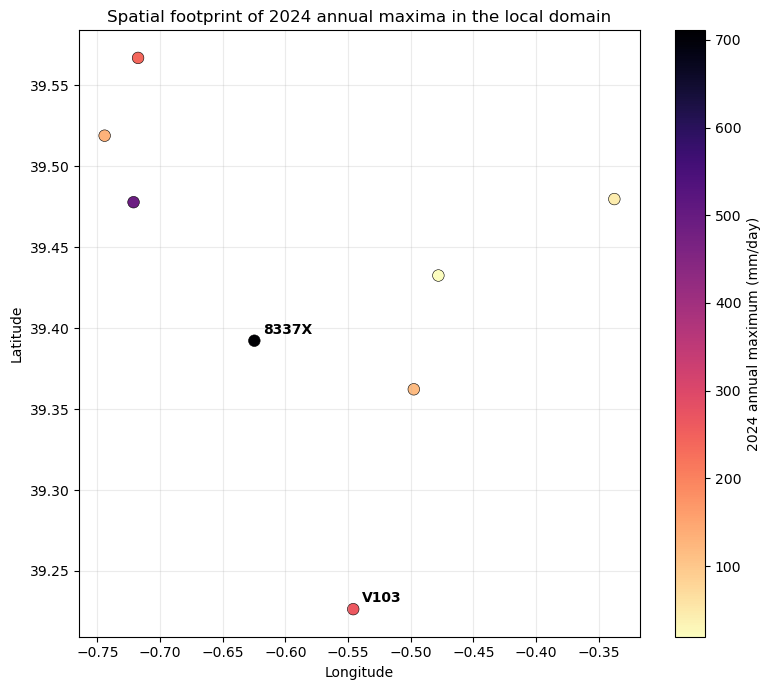

In [13]:
if 2024 in ams_hier_local_with_dana.index:
    spatial_2024 = ams_hier_local_with_dana.loc[2024].rename('max_2024').to_frame()
    spatial_2024 = spatial_2024.join(stations_meta[['Longitud', 'Latitud']], how='left').dropna()
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(spatial_2024['Longitud'], spatial_2024['Latitud'],
                    c=spatial_2024['max_2024'], s=70, cmap='magma_r', edgecolor='black', linewidth=0.4)
    for station, row in spatial_2024.loc[spatial_2024.index.isin(core_stations)].iterrows():
        ax.annotate(station, (row['Longitud'], row['Latitud']), xytext=(6, 5), textcoords='offset points', fontsize=10, weight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Spatial footprint of 2024 annual maxima in the local domain')
    ax.grid(True, alpha=0.25)
    fig.colorbar(sc, ax=ax, label='2024 annual maximum (mm/day)')
    plt.tight_layout()
    plt.show()


---
## 3. Point GEV analysis with `pyhydra`

This section recomputes point estimates for the two core stations using `fit_gev_mle`, `fit_gev_lmom`, and `return_level`.


In [14]:
def point_table(ams, scenario_label):
    rows = []
    for station in core_stations:
        values = ams[station].dropna().values
        mle = fit_gev_mle(values)
        lmom = fit_gev_lmom(values)
        for T in T_VALUES:
            rows.append({
                'Station': station,
                'Scenario': scenario_label,
                'N': len(values),
                'T': T,
                'MLE': float(return_level(mle, T)),
                'L-Moments': float(return_level(lmom, T)),
                'xi_mle': mle['xi'],
                'xi_lmom': lmom['xi'],
            })
    return pd.DataFrame(rows)

point_pyhydra = pd.concat([
    point_table(ams_without_dana, 'Without DANA'),
    point_table(ams_with_dana, 'With DANA'),
], ignore_index=True)

point_pyhydra.round(2)


,Station,Scenario,N,T,MLE,L-Moments,xi_mle,xi_lmom
0,8337X,Without DANA,16,10,119.07,119.58,0.22,0.17
1,8337X,Without DANA,16,100,227.04,217.95,0.22,0.17
2,8337X,Without DANA,16,500,340.02,312.00,0.22,0.17
3,V103,Without DANA,24,10,120.84,122.31,0.02,0.02
4,V103,Without DANA,24,100,185.11,188.62,0.02,0.02
5,V103,Without DANA,24,500,230.91,235.81,0.02,0.02
6,8337X,With DANA,17,10,185.66,165.35,0.67,0.70
7,8337X,With DANA,17,100,821.80,755.63,0.67,0.70
8,8337X,With DANA,17,500,2373.88,2284.36,0.67,0.70
9,V103,With DANA,25,10,140.60,141.45,0.19,0.24


---
## 4. Point Bayesian analysis with PyMC

The original study compared Bayesian, MLE and L-moment point estimates. This block regenerates that layer with `pyhydra.fit_gev_bayes`, with MCMC length controlled by environment variables.


Calibration note: for comparison with the archived Valencia PyStan workflow, the PyMC GEV fits use `prior='stan'`. This reproduces the original Stan prior structure (`mu ~ Normal(0, 100)`, `sigma ~ HalfCauchy(5)`, `xi ~ Normal(0, 5)`) and the same hard GEV support constraint. Use the default MCMC controls below for exploratory checks, and increase `HYDRA_PYMC_DRAWS` and `HYDRA_PYMC_WARMUP` for deposit-quality posterior summaries.


In [15]:
def point_bayes_fit_table():
    posteriors = {}
    rows = []
    if not (RUN_PYMC_POINT and PYMC_AVAILABLE):
        print('Point PyMC skipped. Set HYDRA_RUN_PYMC_POINT=1 and install PyMC to run it.')
        return pd.DataFrame(), posteriors
    for scenario, ams in [('Without DANA', ams_without_dana), ('With DANA', ams_with_dana)]:
        for station in core_stations:
            values = ams[station].dropna().values.astype(float)
            posterior = fit_gev_bayes(values, n_chains=PYMC_CHAINS, n_samples=PYMC_DRAWS,
                                      warmup=PYMC_WARMUP, adapt_delta=PYMC_ADAPT_DELTA,
                                      progressbar=PYMC_PROGRESS, random_seed=PYMC_SEED, prior='stan')
            posteriors[(station, scenario)] = posterior
            for T in T_VALUES:
                ci = return_level_bayes(posterior, T, credible=0.95)
                rows.append({'Station': station, 'Scenario': scenario, 'T': T,
                             'Bayes_p2_5': ci['lower'], 'Bayes_median': ci['median'], 'Bayes_p97_5': ci['upper']})
    return pd.DataFrame(rows), posteriors

point_bayes_pyhydra, point_bayes_posteriors = point_bayes_fit_table()
point_bayes_pyhydra.round(2)


Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_raw, sigma, xi]
Sampling 2 chains for 80 tune and 80 draw iterations (160 + 160 draws total) took 0 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.
Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_raw, sigma, xi]
Sampling 2 chains for 80 tune and 80 draw iterations (160 + 160 draws total) took 1 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The number of samples is too sma

,Station,Scenario,T,Bayes_p2_5,Bayes_median,Bayes_p97_5
0,8337X,Without DANA,10,90.83,125.00,243.41
1,8337X,Without DANA,100,149.95,218.48,1019.01
2,8337X,Without DANA,500,170.79,317.03,3364.95
3,V103,Without DANA,10,4.22,102.28,164.23
4,V103,Without DANA,100,4.23,132.08,331.78
5,V103,Without DANA,500,4.23,141.61,523.44
6,8337X,With DANA,10,124.74,209.65,333.08
7,8337X,With DANA,100,304.21,737.62,2119.17
8,8337X,With DANA,500,511.95,1634.15,7968.83
9,V103,With DANA,10,54.96,162.41,186.77


### Point PyMC versus archived PyStan

This table audits the calibrated PyMC point fit against the archived PyStan point results from the original Valencia workflow.


In [ ]:
stan_point_reference = pd.read_csv(STAN_REF_DIR / 'resultados_regional_pequeno.csv')
stan_point_reference = stan_point_reference[
    stan_point_reference['Type'].eq('Point') &
    stan_point_reference['Station'].isin(core_stations) &
    stan_point_reference['Return Period'].isin(T_VALUES)
][['Station', 'DANA', 'Return Period', 'Bayes_median', 'Bayes_p2_5', 'Bayes_p97_5']]

if not point_bayes_pyhydra.empty:
    point_pymc_vs_stan = point_bayes_pyhydra.rename(columns={'Scenario': 'DANA', 'T': 'Return Period'}).merge(
        stan_point_reference,
        on=['Station', 'DANA', 'Return Period'],
        how='left',
    )
    point_pymc_vs_stan['median_delta'] = point_pymc_vs_stan['Bayes_median_x'] - point_pymc_vs_stan['Bayes_median_y']
    point_pymc_vs_stan['median_rel_pct'] = 100 * point_pymc_vs_stan['median_delta'] / point_pymc_vs_stan['Bayes_median_y']
    point_pymc_vs_stan = point_pymc_vs_stan.rename(columns={
        'Bayes_median_x': 'PyMC_median',
        'Bayes_p2_5_x': 'PyMC_p2_5',
        'Bayes_p97_5_x': 'PyMC_p97_5',
        'Bayes_median_y': 'Stan_median',
        'Bayes_p2_5_y': 'Stan_p2_5',
        'Bayes_p97_5_y': 'Stan_p97_5',
    })
    display(point_pymc_vs_stan.round(2))
else:
    print('Point PyMC table is empty.')


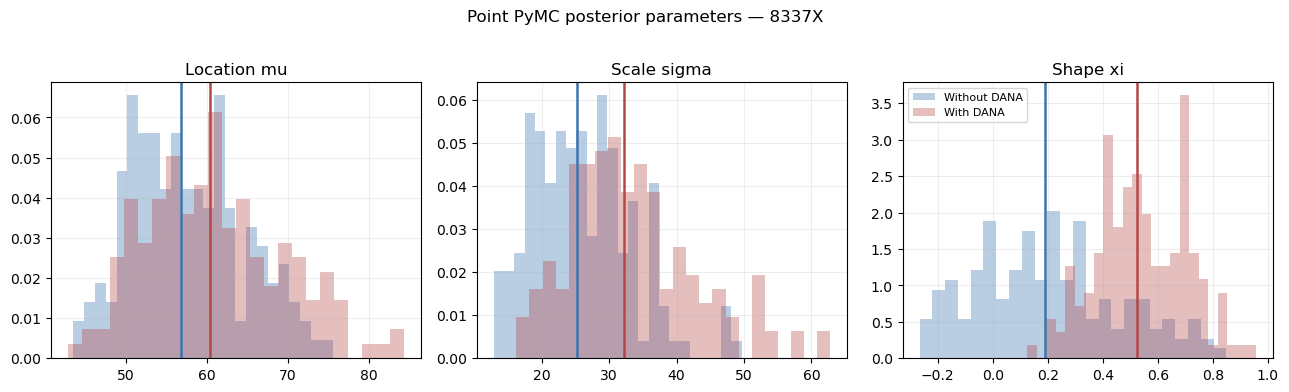

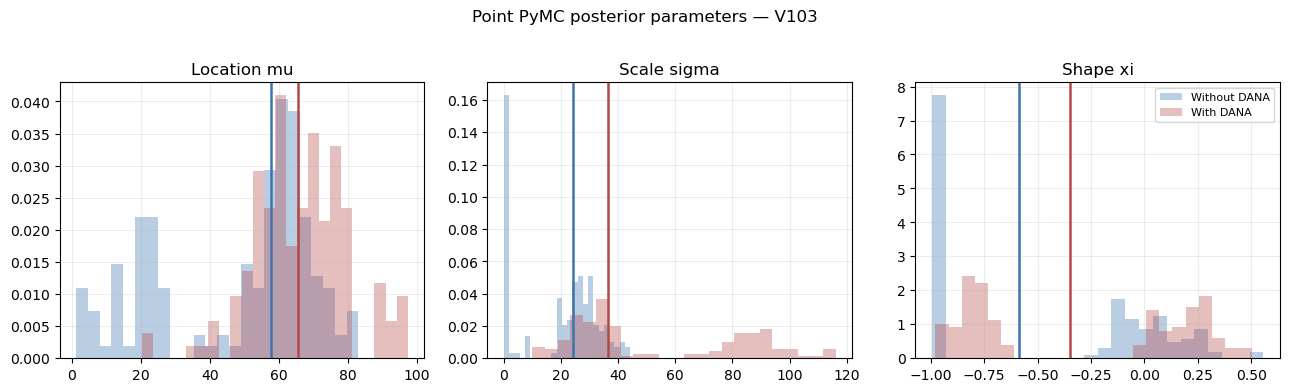

In [16]:
def plot_point_posterior_parameters(station):
    if not point_bayes_posteriors:
        print('No point PyMC posterior available.')
        return
    params = [('mu', 'Location mu'), ('sigma', 'Scale sigma'), ('xi', 'Shape xi')]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, (param, label) in zip(axes, params):
        for scenario, color in [('Without DANA', '#3b75af'), ('With DANA', '#b54747')]:
            posterior = point_bayes_posteriors[(station, scenario)]
            ax.hist(posterior[param].values, bins=24, density=True, alpha=0.35, color=color, label=scenario)
            ax.axvline(posterior[param].median(), color=color, linewidth=1.8)
        ax.set_title(label)
        ax.grid(True, alpha=0.22)
    axes[-1].legend(fontsize=8)
    fig.suptitle(f'Point PyMC posterior parameters — {station}', y=1.02)
    plt.tight_layout()
    plt.show()

for station in core_stations:
    plot_point_posterior_parameters(station)


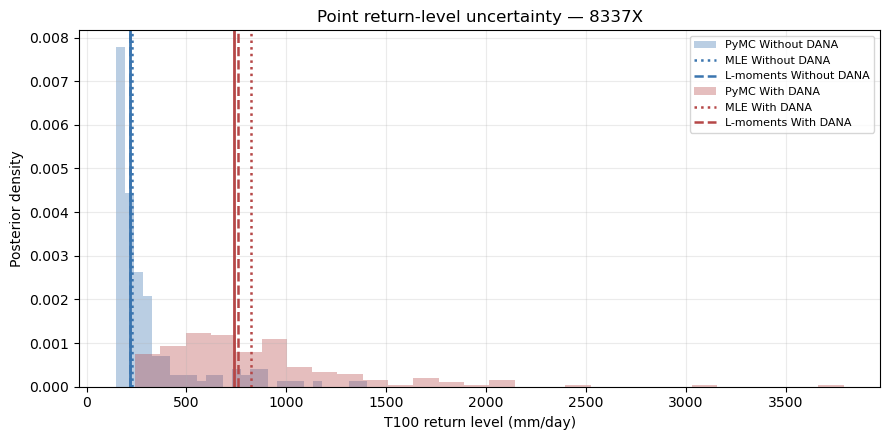

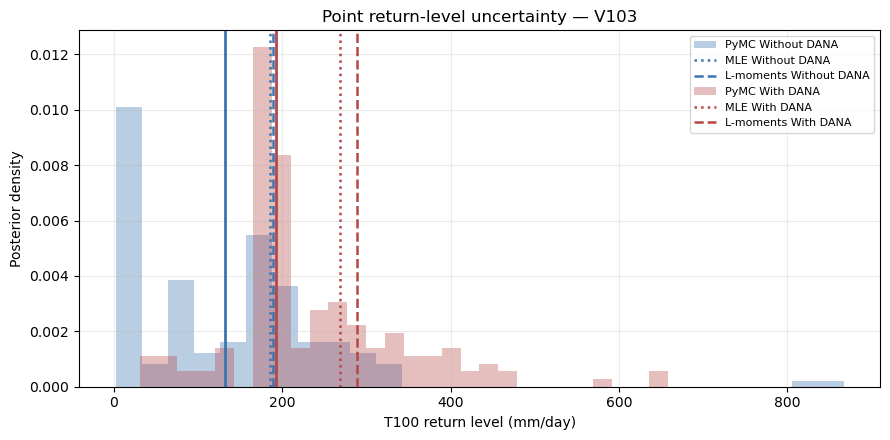

In [17]:
from scipy.stats import genextreme

def posterior_return_level_samples(posterior, T):
    levels = genextreme.ppf(1 - 1 / T, -posterior['xi'].values, loc=posterior['mu'].values, scale=posterior['sigma'].values)
    return levels[np.isfinite(levels)]


def plot_point_return_level_distributions(station, T=100):
    if not point_bayes_posteriors:
        print('No point PyMC posterior available.')
        return
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for scenario, color in [('Without DANA', '#3b75af'), ('With DANA', '#b54747')]:
        levels = posterior_return_level_samples(point_bayes_posteriors[(station, scenario)], T)
        ax.hist(levels, bins=28, density=True, alpha=0.35, color=color, label=f'PyMC {scenario}')
        ax.axvline(np.median(levels), color=color, linewidth=2)
        ams = ams_without_dana if scenario == 'Without DANA' else ams_with_dana
        mle = fit_gev_mle(ams[station].dropna().values)
        lmom = fit_gev_lmom(ams[station].dropna().values)
        ax.axvline(return_level(mle, T), color=color, linestyle=':', linewidth=1.8, label=f'MLE {scenario}')
        ax.axvline(return_level(lmom, T), color=color, linestyle='--', linewidth=1.8, label=f'L-moments {scenario}')
    ax.set_xlabel(f'T{T} return level (mm/day)')
    ax.set_ylabel('Posterior density')
    ax.set_title(f'Point return-level uncertainty — {station}')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for station in core_stations:
    plot_point_return_level_distributions(station, T=100)


---
### Return-period diagnostic curves

The following plots mirror the original return-period comparison figures, but use `pyhydra` fits and empirical plotting positions directly from the HYDRA annual maxima.


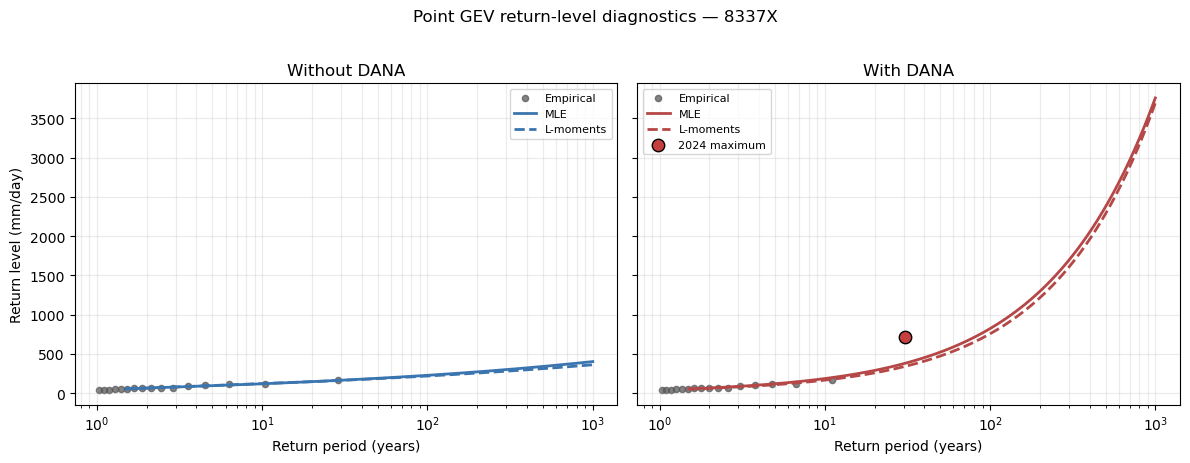

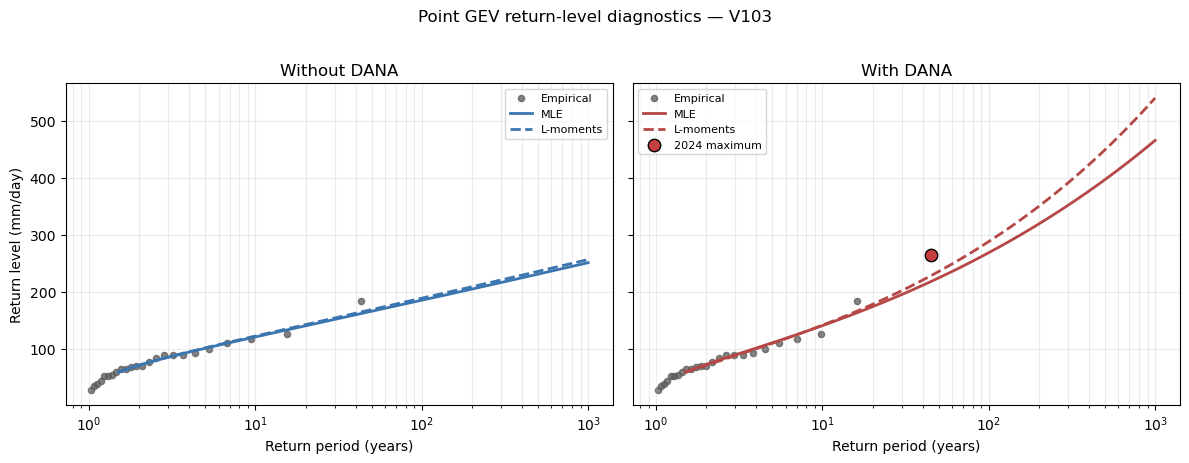

In [18]:
def empirical_return_period_points(values):
    arr = np.sort(np.asarray(values, dtype=float))
    arr = arr[np.isfinite(arr)]
    n = len(arr)
    prob = (np.arange(1, n + 1) - 0.44) / (n + 0.12)
    T = 1.0 / (1.0 - prob)
    return T, arr


def plot_point_return_curves(station):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, (scenario, ams, color) in zip(
        axes,
        [('Without DANA', ams_without_dana, '#3b75af'), ('With DANA', ams_with_dana, '#b54747')],
    ):
        values = ams[station].dropna().values
        T_emp, y_emp = empirical_return_period_points(values)
        mle = fit_gev_mle(values)
        lmom = fit_gev_lmom(values)
        T_grid = np.geomspace(1.5, 1000, 180)
        ax.scatter(T_emp, y_emp, s=20, color='0.35', alpha=0.75, label='Empirical')
        ax.plot(T_grid, [return_level(mle, T) for T in T_grid], color=color, linewidth=2, label='MLE')
        ax.plot(T_grid, [return_level(lmom, T) for T in T_grid], color=color, linewidth=2, linestyle='--', label='L-moments')
        if 2024 in ams.index and pd.notna(ams.loc[2024, station]):
            ax.scatter([max(T_emp)], [ams.loc[2024, station]], s=80, color='#c63f3f', edgecolor='black', zorder=4, label='2024 maximum')
        ax.set_xscale('log')
        ax.set_xlabel('Return period (years)')
        ax.set_title(scenario)
        ax.grid(True, which='both', alpha=0.25)
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Return level (mm/day)')
    fig.suptitle(f'Point GEV return-level diagnostics — {station}', y=1.02)
    plt.tight_layout()
    plt.show()

for station in core_stations:
    plot_point_return_curves(station)


---
## 4. Regional Frequency Analysis with `pyhydra`

A regional GEV is fitted to index-flood-normalised annual maxima. The Hosking-Wallis diagnostics are also computed for the selected regional station set.


In [19]:
def as_data_dict(ams):
    return {station: ams[station].dropna().values for station in regional_small}

def regional_table(ams, scenario_label):
    data_dict = as_data_dict(ams)
    rows = []
    for method in ['mle', 'lmom']:
        rl = regional_return_levels(data_dict, T_VALUES, method=method)
        for station in core_stations:
            for T in T_VALUES:
                rows.append({
                    'Station': station,
                    'Scenario': scenario_label,
                    'T': T,
                    'Type': 'Regional (RFA)',
                    'Method': method.upper() if method == 'mle' else 'L-Moments',
                    'Return level': float(rl.loc[station, f'T{T}']),
                })
    return pd.DataFrame(rows)

regional_pyhydra = pd.concat([
    regional_table(ams_without_dana, 'Without DANA'),
    regional_table(ams_with_dana, 'With DANA'),
], ignore_index=True)

regional_pyhydra.pivot_table(
    index=['Station', 'Scenario', 'T'], columns='Method', values='Return level'
).round(2)


Method                    L-Moments     MLE
Station Scenario     T                     
8337X   With DANA    10      189.47  189.20
                     100     436.99  424.34
                     500     752.30  712.78
        Without DANA 10      119.57  119.67
                     100     208.87  214.77
                     500     288.16  303.44
V103    With DANA    10      144.19  143.98
                     100     332.55  322.93
                     500     572.51  542.43
        Without DANA 10      125.01  125.11
                     100     218.37  224.53
                     500     301.27  317.24

In [20]:
for label, ams in [('Without DANA', ams_without_dana), ('With DANA', ams_with_dana)]:
    data_dict = as_data_dict(ams)
    print()
    print(label)
    try:
        disc = regional_discordancy(data_dict)
        print('Discordancy:')
        print(disc.round(3).to_string())
    except Exception as exc:
        print(f'Discordancy unavailable: {type(exc).__name__}: {exc}')
    try:
        het = regional_heterogeneity(data_dict, n_sim=300, seed=42)
        print('Heterogeneity H1:', round(het['H'], 3),
              f"(V_obs={het['V_obs']:.4f}, null={het['V_sim_mean']:.4f} ± {het['V_sim_std']:.4f})")
    except Exception as exc:
        print(f'Heterogeneity unavailable: {type(exc).__name__}: {exc}')



Without DANA
Discordancy:
               Di  critical  discordant
8309X       2.110     2.632       False
8337X       0.187     2.632       False
8414A       0.859     2.632       False
8416X       1.025     2.632       False
V01         2.784     2.632        True
V05         0.617     2.632       False
V103        0.570     2.632       False
V17         1.116     2.632       False
c16m244e01  0.036     2.632       False
c18m109e01  1.422     2.632       False
c18m111e01  0.275     2.632       False
Heterogeneity H1: -0.159 (V_obs=0.0408, null=0.0424 ± 0.0105)

With DANA
Discordancy:
               Di  critical  discordant
8309X       1.932     2.632       False
8337X       1.483     2.632       False
8414A       0.486     2.632       False
8416X       0.960     2.632       False
V01         0.798     2.632       False
V05         0.904     2.632       False
V103        0.304     2.632       False
V17         1.197     2.632       False
c16m244e01  0.846     2.632       False
c18m109

/opt/anaconda3/lib/python3.12/site-packages/lmoments3/distr.py:579: RuntimeWarning: invalid value encountered in power
  np.where(k == 0, 0.0, (1 - h ** (-k)) / k),


---
## 5. Original paper RFA workflow with PyMC

The original Valencia paper notebooks did not use the current index-flood implementation for the archived RFA tables. They standardised each station with a `StandardScaler`, built one regional series as the annual maximum across the standardised stations, fitted a GEV to that regional series, and transformed the return levels back to each station using that station's mean and standard deviation. This block reproduces that workflow with `pyhydra`/PyMC.


In [21]:
def standardised_regional_series(ams):
    means = ams.mean(axis=0, skipna=True)
    scales = pd.Series(np.nanstd(ams.values, axis=0, ddof=0), index=ams.columns).replace(0.0, np.nan)
    standardised = (ams - means) / scales
    regional = standardised.max(axis=1, skipna=True).dropna().values.astype(float)
    return regional, means, scales


paper_rfa_posteriors = {}

def paper_rfa_table(ams, scenario_label, domain_label, stations_to_report, run_bayes=True):
    regional_series, means, scales = standardised_regional_series(ams)
    mle = fit_gev_mle(regional_series)
    lmom = fit_gev_lmom(regional_series)
    posterior = None
    if run_bayes and PYMC_AVAILABLE:
        posterior = fit_gev_bayes(
            regional_series,
            n_chains=PYMC_CHAINS,
            n_samples=PYMC_DRAWS,
            warmup=PYMC_WARMUP,
            adapt_delta=PYMC_ADAPT_DELTA,
            progressbar=PYMC_PROGRESS,
            random_seed=PYMC_SEED,
            prior='stan',
        )
        paper_rfa_posteriors[(domain_label, scenario_label)] = {
            'posterior': posterior,
            'means': means,
            'scales': scales,
            'regional_series': regional_series,
        }

    rows = []
    for station in stations_to_report:
        for T in T_VALUES:
            mle_value = float(return_level(mle, T) * scales[station] + means[station])
            lmom_value = float(return_level(lmom, T) * scales[station] + means[station])
            row = {
                'Domain': domain_label,
                'Station': station,
                'Return Period': T,
                'DANA': scenario_label,
                'Type': 'Regional (RFA)',
                'MLE': mle_value,
                'L-Moments': lmom_value,
            }
            if posterior is not None:
                ci = return_level_bayes(posterior, T, credible=0.95)
                row.update({
                    'Bayes_p2_5': float(ci['lower'] * scales[station] + means[station]),
                    'Bayes_median': float(ci['median'] * scales[station] + means[station]),
                    'Bayes_p97_5': float(ci['upper'] * scales[station] + means[station]),
                })
            rows.append(row)
    return pd.DataFrame(rows)

paper_rfa_frames = []
if RUN_PYMC_RFA and PYMC_AVAILABLE:
    paper_rfa_frames.extend([
        paper_rfa_table(ams_without_dana, 'Without DANA', 'Local', core_stations),
        paper_rfa_table(ams_with_dana, 'With DANA', 'Local', core_stations),
    ])
else:
    print('PyMC RFA skipped. Set HYDRA_RUN_PYMC_RFA=1 and install PyMC to run it.')

paper_rfa_pyhydra = pd.concat(paper_rfa_frames, ignore_index=True) if paper_rfa_frames else pd.DataFrame()
paper_rfa_pyhydra.round(2)


Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_raw, sigma, xi]
Sampling 2 chains for 80 tune and 80 draw iterations (160 + 160 draws total) took 1 seconds.
The number of samples is too small to check convergence reliably.
Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_raw, sigma, xi]
Sampling 2 chains for 80 tune and 80 draw iterations (160 + 160 draws total) took 0 seconds.
The number of samples is too small to check convergence reliably.


,Domain,Station,Return Period,DANA,Type,MLE,L-Moments,Bayes_p2_5,Bayes_median,Bayes_p97_5
0,Local,8337X,10,Without DANA,Regional (RFA),145.50,146.86,23.21,136.81,173.29
1,Local,8337X,100,Without DANA,Regional (RFA),233.02,231.45,23.21,184.75,374.42
2,Local,8337X,500,Without DANA,Regional (RFA),298.98,292.42,23.21,194.98,551.82
3,Local,V103,10,Without DANA,Regional (RFA),147.62,148.95,27.44,139.08,174.93
4,Local,V103,100,Without DANA,Regional (RFA),233.62,232.08,27.44,186.19,372.58
5,Local,V103,500,Without DANA,Regional (RFA),298.44,292.00,27.44,196.24,546.91
6,Local,8337X,10,With DANA,Regional (RFA),435.02,437.05,375.36,444.75,618.33
7,Local,8337X,100,With DANA,Regional (RFA),911.73,919.35,672.97,951.53,1745.20
8,Local,8337X,500,With DANA,Regional (RFA),1327.75,1340.92,838.15,1423.77,3460.00
9,Local,V103,10,With DANA,Regional (RFA),188.92,189.57,169.71,192.05,247.94


### Paper-style RFA PyMC versus archived PyStan

This table checks the PyMC regional fit against the archived Stan regional results. The deterministic MLE/L-moment columns are expected to match exactly up to numerical precision; the Bayesian columns should be compared by posterior summaries.


In [ ]:
stan_rfa_reference = pd.read_csv(STAN_REF_DIR / 'resultados_regional_pequeno.csv')
stan_rfa_reference = stan_rfa_reference[
    stan_rfa_reference['Type'].eq('Regional (RFA)') &
    stan_rfa_reference['Station'].isin(core_stations) &
    stan_rfa_reference['Return Period'].isin(T_VALUES)
][['Station', 'DANA', 'Return Period', 'Bayes_median', 'Bayes_p2_5', 'Bayes_p97_5', 'MLE', 'L-Moments']]

if not paper_rfa_pyhydra.empty:
    rfa_pymc_vs_stan = paper_rfa_pyhydra.merge(
        stan_rfa_reference,
        on=['Station', 'DANA', 'Return Period'],
        how='left',
        suffixes=('_pymc', '_stan'),
    )
    rfa_pymc_vs_stan['median_delta'] = rfa_pymc_vs_stan['Bayes_median_pymc'] - rfa_pymc_vs_stan['Bayes_median_stan']
    rfa_pymc_vs_stan['median_rel_pct'] = 100 * rfa_pymc_vs_stan['median_delta'] / rfa_pymc_vs_stan['Bayes_median_stan']
    display(rfa_pymc_vs_stan.round(2))
else:
    print('Paper-style RFA PyMC table is empty.')


---
### Paper-style RFA uncertainty figures

The original study used distribution and comparative plots to show how regionalisation changes design rainfall. Here the PyMC posterior intervals are shown for the paper-style RFA workflow.


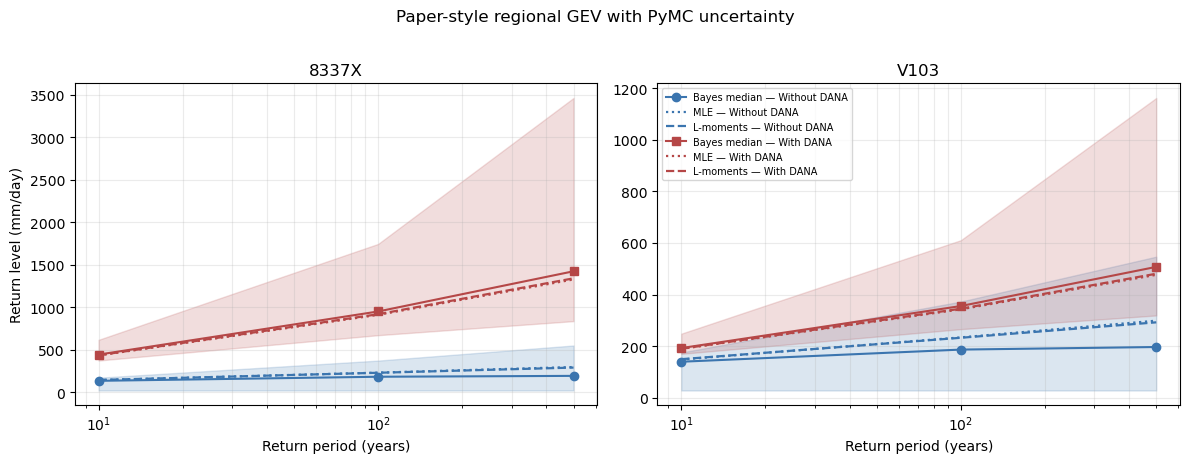

In [22]:
if not paper_rfa_pyhydra.empty:
    fig, axes = plt.subplots(1, len(core_stations), figsize=(12, 4.5), sharey=False)
    axes = np.atleast_1d(axes)
    for ax, station in zip(axes, core_stations):
        sub = paper_rfa_pyhydra[paper_rfa_pyhydra['Station'].eq(station)].copy()
        for scenario, color, marker in [('Without DANA', '#3b75af', 'o'), ('With DANA', '#b54747', 's')]:
            ss = sub[sub['DANA'].eq(scenario)].sort_values('Return Period')
            ax.plot(ss['Return Period'], ss['Bayes_median'], marker=marker, color=color, label=f'Bayes median — {scenario}')
            ax.fill_between(ss['Return Period'], ss['Bayes_p2_5'], ss['Bayes_p97_5'], color=color, alpha=0.18)
            ax.plot(ss['Return Period'], ss['MLE'], color=color, linestyle=':', linewidth=1.6, label=f'MLE — {scenario}')
            ax.plot(ss['Return Period'], ss['L-Moments'], color=color, linestyle='--', linewidth=1.6, label=f'L-moments — {scenario}')
        ax.set_xscale('log')
        ax.set_title(station)
        ax.set_xlabel('Return period (years)')
        ax.grid(True, which='both', alpha=0.25)
    axes[0].set_ylabel('Return level (mm/day)')
    axes[-1].legend(fontsize=7, loc='best')
    fig.suptitle('Paper-style regional GEV with PyMC uncertainty', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('paper_rfa_pyhydra is empty; enable HYDRA_RUN_PYMC_RFA=1 to draw these figures.')


---
### Regional versus point uncertainty

These plots reproduce the regional-vs-punctual comparison logic of the Valencia paper: for a fixed return period, compare the posterior distribution obtained from the station-only fit with the paper-style regional PyMC fit rescaled to the station.


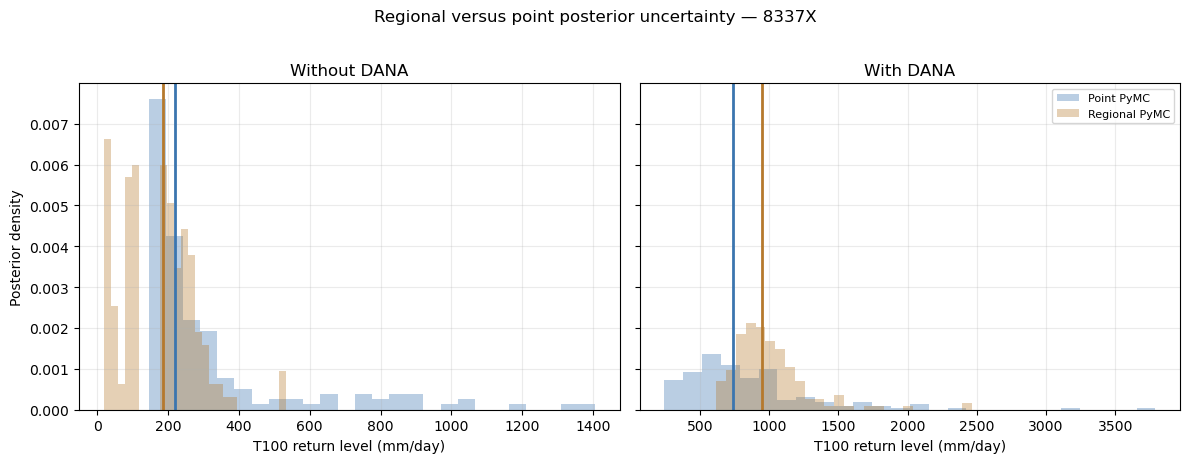

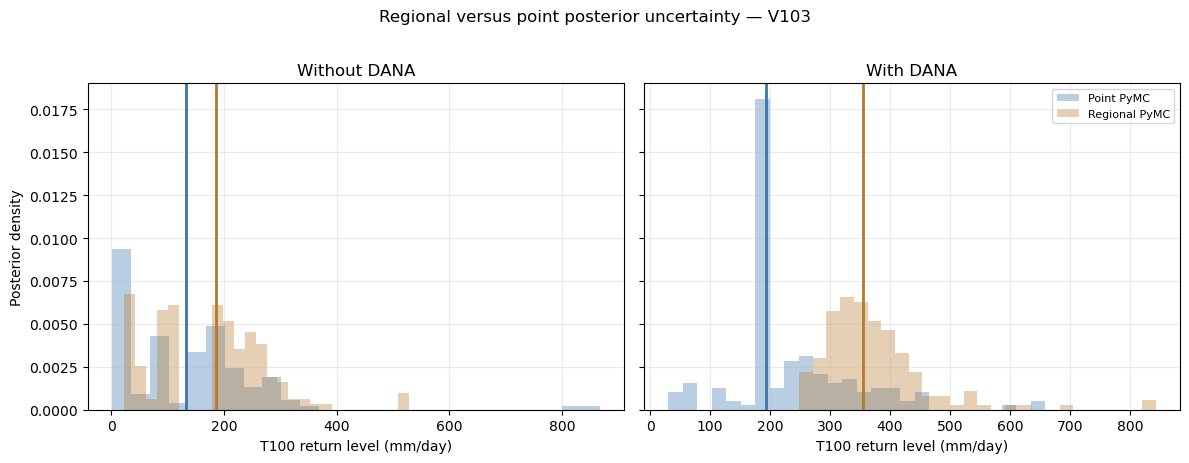

In [23]:
def paper_rfa_return_level_samples(domain_label, scenario, station, T):
    cache = paper_rfa_posteriors.get((domain_label, scenario))
    if cache is None:
        return np.array([])
    posterior = cache['posterior']
    raw = posterior_return_level_samples(posterior, T)
    return raw * cache['scales'][station] + cache['means'][station]


def plot_regional_vs_point_density(station, T=100):
    if not point_bayes_posteriors or not paper_rfa_posteriors:
        print('Point or regional PyMC posterior unavailable.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, scenario in zip(axes, ['Without DANA', 'With DANA']):
        point_levels = posterior_return_level_samples(point_bayes_posteriors[(station, scenario)], T)
        regional_levels = paper_rfa_return_level_samples('Local', scenario, station, T)
        ax.hist(point_levels, bins=26, density=True, alpha=0.35, color='#3b75af', label='Point PyMC')
        ax.hist(regional_levels, bins=26, density=True, alpha=0.35, color='#b5792d', label='Regional PyMC')
        ax.axvline(np.median(point_levels), color='#3b75af', linewidth=2)
        ax.axvline(np.median(regional_levels), color='#b5792d', linewidth=2)
        ax.set_title(scenario)
        ax.set_xlabel(f'T{T} return level (mm/day)')
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel('Posterior density')
    axes[-1].legend(fontsize=8)
    fig.suptitle(f'Regional versus point posterior uncertainty — {station}', y=1.02)
    plt.tight_layout()
    plt.show()

for station in core_stations:
    plot_regional_vs_point_density(station, T=100)


---
## 6. Hierarchical GEV with PyMC

This block reproduces the Stan hierarchical analysis with `pyhydra.climate.spatial_analysis.HierarchicalGEV`. The local domain corresponds to `Gev_hicherical_Pequeño.ipynb`; the general domain corresponds to `Gev_hicherical_Grande.ipynb` and contains all V2 stations from 2000 onward. Hierarchical MCMC is disabled by default because it is expensive, especially in restricted environments that force PyTensor to use the pure-Python linker. Run the local reproduction with `HYDRA_RUN_PYMC_HIER_LOCAL=1`; run the full general-domain reproduction with `HYDRA_RUN_PYMC_HIER_GENERAL=1`.


In [24]:
def gev_return_level_samples(mu, sigma, xi, T):
    p = 1.0 - 1.0 / T
    nl = -np.log(p)
    gev = mu + (sigma / xi) * (nl ** (-xi) - 1.0)
    gumbel = mu - sigma * np.log(nl)
    return np.where(np.abs(xi) > 1e-6, gev, gumbel)


def fit_hierarchical_pymc(ams, domain_label):
    data_dict = {station: ams[station].dropna().values.astype(float) for station in ams.columns}
    model = HierarchicalGEV(
        T_values=T_VALUES,
        n_chains=PYMC_CHAINS,
        n_samples=PYMC_DRAWS,
        warmup=PYMC_WARMUP,
        adapt_delta=PYMC_ADAPT_DELTA,
        progressbar=PYMC_PROGRESS,
        random_seed=PYMC_SEED,
    )
    print(f'Fitting hierarchical PyMC model for {domain_label}: {len(data_dict)} stations')
    return model.fit(data_dict)


def hierarchical_return_table(model, scenario_label, domain_label, stations_to_report):
    regional = model.return_levels(credible=0.95)
    posterior = model._idata.posterior
    mu_pop = posterior['mu_pop'].values.flatten()
    sigma_pop = posterior['sigma_pop'].values.flatten()
    xi_pop = posterior['xi_pop'].values.flatten()

    rows = []
    for station in stations_to_report:
        for T in T_VALUES:
            rows.append({
                'Domain': domain_label,
                'Station': station,
                'Return Period': T,
                'DANA': scenario_label,
                'Method': 'Regional',
                'Median': regional.loc[station, f'T{T}_median'],
                'Percentile 2.5': regional.loc[station, f'T{T}_lower'],
                'Percentile 97.5': regional.loc[station, f'T{T}_upper'],
            })
            global_levels = gev_return_level_samples(mu_pop, sigma_pop, xi_pop, T)
            global_levels = global_levels[np.isfinite(global_levels)]
            rows.append({
                'Domain': domain_label,
                'Station': station,
                'Return Period': T,
                'DANA': scenario_label,
                'Method': 'Global',
                'Median': float(np.median(global_levels)),
                'Percentile 2.5': float(np.quantile(global_levels, 0.025)),
                'Percentile 97.5': float(np.quantile(global_levels, 0.975)),
            })
    return pd.DataFrame(rows)

hierarchical_frames = []
if PYMC_AVAILABLE and RUN_PYMC_HIER_LOCAL:
    local_without_model = fit_hierarchical_pymc(ams_hier_local_without_dana, 'Local / without DANA')
    local_with_model = fit_hierarchical_pymc(ams_hier_local_with_dana, 'Local / with DANA')
    hierarchical_frames.extend([
        hierarchical_return_table(local_without_model, 'Without DANA', 'Local', core_stations),
        hierarchical_return_table(local_with_model, 'With DANA', 'Local', core_stations),
    ])
else:
    print('Local hierarchical PyMC skipped. Set HYDRA_RUN_PYMC_HIER_LOCAL=1 and install PyMC to run it.')

if PYMC_AVAILABLE and RUN_PYMC_HIER_GENERAL:
    general_without_model = fit_hierarchical_pymc(ams_hier_general_without_dana, 'General / without DANA')
    general_with_model = fit_hierarchical_pymc(ams_hier_general_with_dana, 'General / with DANA')
    hierarchical_frames.extend([
        hierarchical_return_table(general_without_model, 'Without DANA', 'General', core_stations),
        hierarchical_return_table(general_with_model, 'With DANA', 'General', core_stations),
    ])
else:
    print('General hierarchical PyMC skipped by default. Set HYDRA_RUN_PYMC_HIER_GENERAL=1 for the full general-domain run.')

hierarchical_pyhydra = pd.concat(hierarchical_frames, ignore_index=True) if hierarchical_frames else pd.DataFrame()
hierarchical_pyhydra.round(2)


Local hierarchical PyMC skipped. Set HYDRA_RUN_PYMC_HIER_LOCAL=1 and install PyMC to run it.
General hierarchical PyMC skipped by default. Set HYDRA_RUN_PYMC_HIER_GENERAL=1 for the full general-domain run.


""


---
## 7. Historical Stan/PyStan reference tables

The original Valencia paper workflow used Stan/PyStan notebooks. Their final CSV tables are archived here as reference outputs, so this HYDRA notebook can compare against them without requiring Stan compilation at runtime.


In [25]:
stan_regional_small = pd.read_csv(STAN_REF_DIR / 'resultados_regional_pequeno.csv')
stan_hier_small = pd.read_csv(STAN_REF_DIR / 'resultados_jerarquico_regional_pequeno.csv')

print('Stan regional small:', stan_regional_small.shape)
print('Stan hierarchical small:', stan_hier_small.shape)
print()
print('Stan regional table sample:')
print(stan_regional_small.head(8).to_string(index=False))


Stan regional small: (132, 9)
Stan hierarchical small: (24, 7)

Stan regional table sample:
Station  Return Period           Type         DANA  Bayes_p2_5  Bayes_p97_5  Bayes_median    MLE  L-Moments
  8337X             10          Point Without DANA       91.93       282.50        125.48 119.07     119.58
  8337X             10          Point    With DANA      113.46       853.42        196.89 185.66     165.35
  8337X             10 Regional (RFA) Without DANA      130.15       184.41        149.71 145.50     146.86
  8337X             10 Regional (RFA)    With DANA      356.81       639.55        456.88 435.00     437.05
  8337X            100          Point Without DANA      141.86      2469.28        258.27 227.05     217.95
  8337X            100          Point    With DANA      268.70     57324.64        960.62 821.80     755.63
  8337X            100 Regional (RFA) Without DANA      186.48       404.77        241.70 233.01     231.45
  8337X            100 Regional (RFA)    Wit

In [26]:
stan_rfa_core = stan_regional_small[
    (stan_regional_small['Station'].isin(core_stations)) &
    (stan_regional_small['Return Period'].isin(T_VALUES)) &
    (stan_regional_small['Type'].eq('Regional (RFA)'))
].copy()

py_rfa = regional_pyhydra.pivot_table(
    index=['Station', 'Scenario', 'T'], columns='Method', values='Return level'
).reset_index().rename(columns={'T': 'Return Period', 'MLE': 'pyhydra_MLE', 'L-Moments': 'pyhydra_L-Moments'})

comparison = py_rfa.merge(
    stan_rfa_core[['Station', 'Return Period', 'DANA', 'MLE', 'L-Moments', 'Bayes_median']],
    left_on=['Station', 'Return Period', 'Scenario'],
    right_on=['Station', 'Return Period', 'DANA'],
    how='left',
).drop(columns=['DANA'])
comparison = comparison.rename(columns={
    'MLE': 'stan_RFA_MLE',
    'L-Moments': 'stan_RFA_L-Moments',
    'Bayes_median': 'stan_RFA_Bayes_median',
})
comparison['delta_lmom_pyhydra_minus_stan'] = comparison['pyhydra_L-Moments'] - comparison['stan_RFA_L-Moments']
comparison.round(2)


,Station,Scenario,Return Period,pyhydra_L-Moments,pyhydra_MLE,stan_RFA_MLE,stan_RFA_L-Moments,stan_RFA_Bayes_median,delta_lmom_pyhydra_minus_stan
0,8337X,With DANA,10,189.47,189.20,435.00,437.05,456.88,-247.58
1,8337X,With DANA,100,436.99,424.34,911.61,919.35,965.59,-482.36
2,8337X,With DANA,500,752.30,712.78,1327.48,1340.92,1417.00,-588.62
3,8337X,Without DANA,10,119.57,119.67,145.50,146.86,149.71,-27.29
4,8337X,Without DANA,100,208.87,214.77,233.01,231.45,241.70,-22.58
5,8337X,Without DANA,500,288.16,303.44,298.96,292.42,310.94,-4.26
6,V103,With DANA,10,144.19,143.98,188.91,189.57,195.96,-45.38
7,V103,With DANA,100,332.55,322.93,342.37,344.86,359.75,-12.31
8,V103,With DANA,500,572.51,542.43,476.26,480.59,505.08,91.92
9,V103,Without DANA,10,125.01,125.11,147.61,148.95,151.75,-23.94


---
## 8. Final comparative figures by method

These figures reproduce the final comparison layer of `Figuras_Finales.ipynb`: methods are combined into a long table and compared by return period and by a fixed design period.


In [27]:
stan_regional_general = pd.read_csv(STAN_REF_DIR / 'resultados_regional_grande.csv')
stan_hier_general = pd.read_csv(STAN_REF_DIR / 'resultados_jerarquico_regional_grande.csv')

def archive_methods_long(regional_df, hierarchical_df, domain_label):
    hier = hierarchical_df[['Station', 'Return Period', 'DANA', 'Method', 'Median']].copy()
    hier = hier.rename(columns={'Median': 'Value'})
    hier['Fit Type'] = 'Hierarchical Bayes'
    hier['Full Method'] = hier['Fit Type'] + ' - ' + hier['Method'] + ' - ' + domain_label

    reg = regional_df.rename(columns={'Type': 'Method', 'Bayes_median': 'Bayes'}).copy()
    other = reg.melt(
        id_vars=['Station', 'Return Period', 'DANA', 'Method'],
        value_vars=['Bayes', 'MLE', 'L-Moments'],
        var_name='Fit Type',
        value_name='Value',
    )
    other['Full Method'] = other['Fit Type'] + ' - ' + other['Method'] + ' - ' + domain_label
    return pd.concat([hier, other], ignore_index=True).dropna(subset=['Value'])

archive_local_long = archive_methods_long(stan_regional_small, stan_hier_small, 'Local')
archive_general_long = archive_methods_long(stan_regional_general, stan_hier_general, 'General')

pyhydra_rfa_long = pd.DataFrame()
if not paper_rfa_pyhydra.empty:
    pyhydra_rfa_long = paper_rfa_pyhydra.melt(
        id_vars=['Domain', 'Station', 'Return Period', 'DANA', 'Type'],
        value_vars=['Bayes_median', 'MLE', 'L-Moments'],
        var_name='Fit Type',
        value_name='Value',
    ).dropna(subset=['Value'])
    pyhydra_rfa_long['Method'] = pyhydra_rfa_long['Type']
    pyhydra_rfa_long['Fit Type'] = pyhydra_rfa_long['Fit Type'].replace({'Bayes_median': 'PyMC Bayes'})
    pyhydra_rfa_long['Full Method'] = pyhydra_rfa_long['Fit Type'] + ' - ' + pyhydra_rfa_long['Method'] + ' - HYDRA ' + pyhydra_rfa_long['Domain']
    pyhydra_rfa_long = pyhydra_rfa_long[['Station', 'Return Period', 'DANA', 'Method', 'Fit Type', 'Value', 'Full Method']]

comparison_methods = pd.concat([archive_local_long, archive_general_long, pyhydra_rfa_long], ignore_index=True)
comparison_methods.head()


,Station,Return Period,DANA,Method,Value,Fit Type,Full Method
0,8337X,10,With DANA,Regional,140.52,Hierarchical Bayes,Hierarchical Bayes - Regional - Local
1,8337X,10,With DANA,Global,128.24,Hierarchical Bayes,Hierarchical Bayes - Global - Local
2,8337X,10,Without DANA,Regional,116.06,Hierarchical Bayes,Hierarchical Bayes - Regional - Local
3,8337X,10,Without DANA,Global,111.27,Hierarchical Bayes,Hierarchical Bayes - Global - Local
4,8337X,100,With DANA,Regional,368.59,Hierarchical Bayes,Hierarchical Bayes - Regional - Local


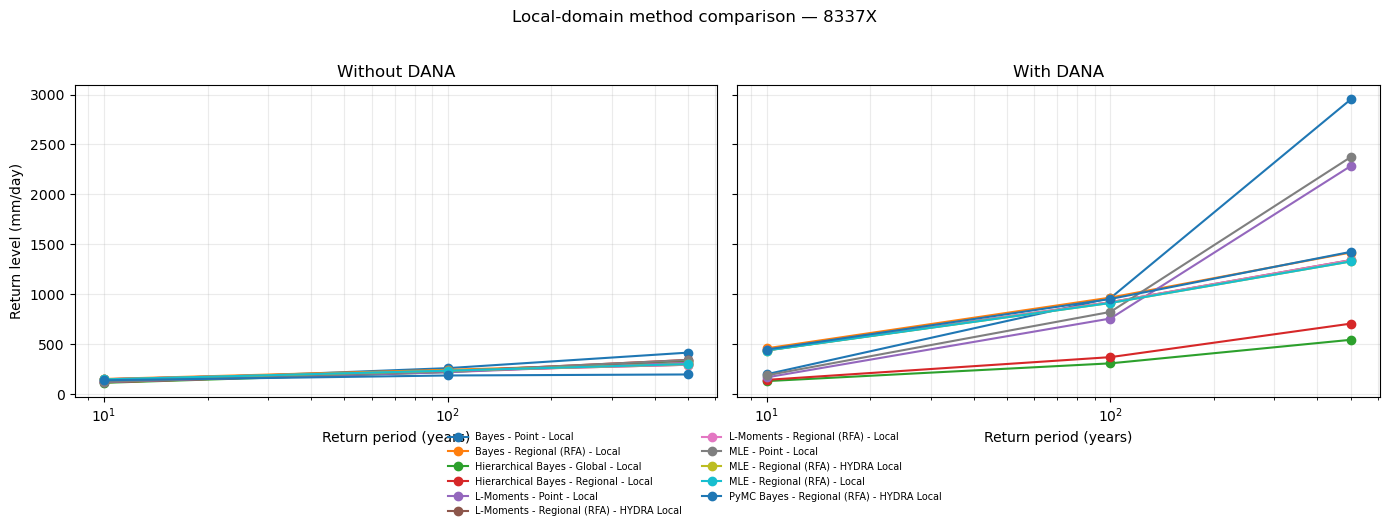

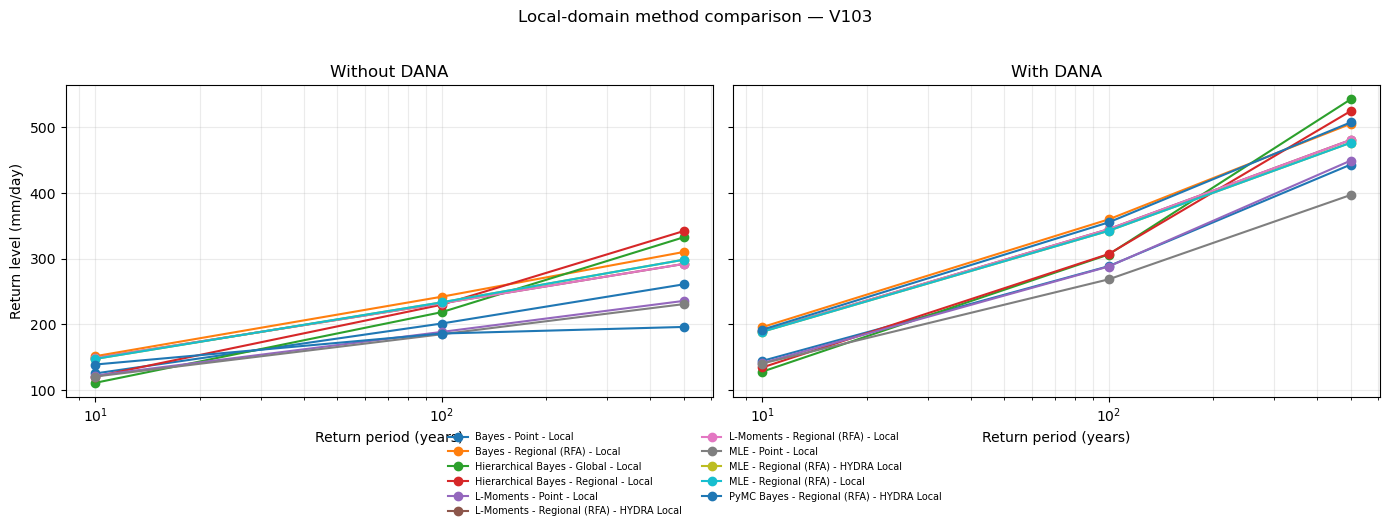

In [28]:
def plot_method_lines(df, station, domain_filter=None, title=None):
    sub = df[df['Station'].eq(station)].copy()
    if domain_filter is not None:
        sub = sub[sub['Full Method'].str.contains(domain_filter, regex=False)]
    methods = sorted(sub['Full Method'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, scenario in zip(axes, ['Without DANA', 'With DANA']):
        ss = sub[sub['DANA'].eq(scenario)]
        for method in methods:
            mm = ss[ss['Full Method'].eq(method)].sort_values('Return Period')
            if mm.empty:
                continue
            ax.plot(mm['Return Period'], mm['Value'], marker='o', linewidth=1.5, label=method)
        ax.set_xscale('log')
        ax.set_xlabel('Return period (years)')
        ax.set_title(scenario)
        ax.grid(True, which='both', alpha=0.25)
    axes[0].set_ylabel('Return level (mm/day)')
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=7, frameon=False)
    fig.suptitle(title or f'Method comparison — {station}', y=1.02)
    plt.tight_layout(rect=[0, 0.12, 1, 1])
    plt.show()

for station in core_stations:
    plot_method_lines(comparison_methods, station, domain_filter='Local', title=f'Local-domain method comparison — {station}')


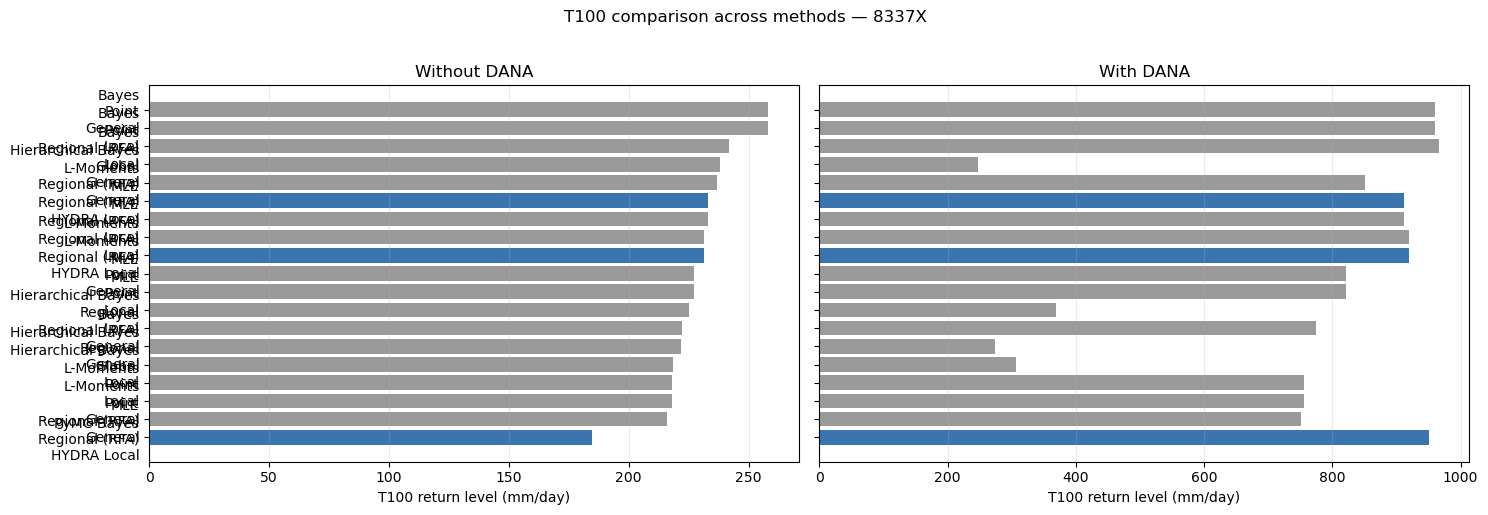

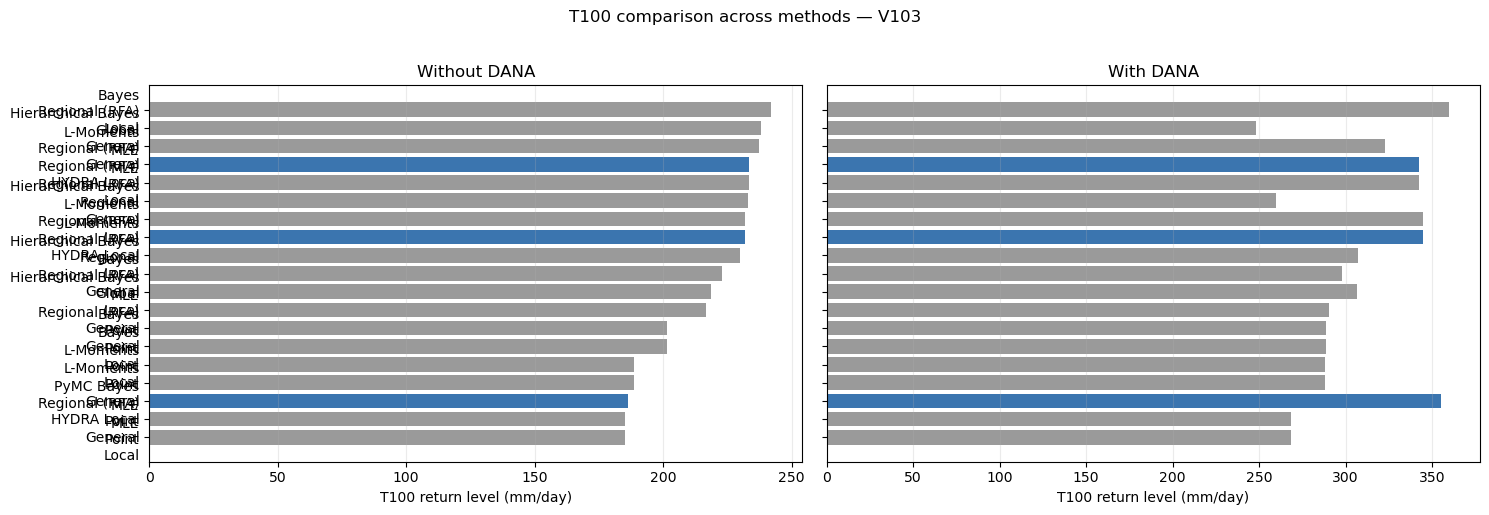

In [29]:
def plot_t100_bars(df, station):
    sub = df[(df['Station'].eq(station)) & (df['Return Period'].eq(100))].copy()
    sub['Label'] = sub['Full Method'].str.replace(' - ', '\n', regex=False)
    scenarios = ['Without DANA', 'With DANA']
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for ax, scenario in zip(axes, scenarios):
        ss = sub[sub['DANA'].eq(scenario)].sort_values('Value')
        colors = ['#3b75af' if 'HYDRA' in label else '#9a9a9a' for label in ss['Full Method']]
        ax.barh(ss['Label'], ss['Value'], color=colors)
        ax.set_title(scenario)
        ax.set_xlabel('T100 return level (mm/day)')
        ax.grid(True, axis='x', alpha=0.25)
    fig.suptitle(f'T100 comparison across methods — {station}', y=1.02)
    plt.tight_layout()
    plt.show()

for station in core_stations:
    plot_t100_bars(comparison_methods, station)


---
### DANA impact as change in precipitation and equivalent return period

The paper used arrows to show two effects: the change in design rainfall at the same return period (Delta P), and the return period that the pre-DANA design rainfall would have after including 2024 (Delta T).


In [30]:
def gev_return_period(params, value):
    prob = genextreme.cdf(value, -params['xi'], loc=params['mu'], scale=params['sigma'])
    exc = max(1.0 - prob, 1e-12)
    return 1.0 / exc


def point_impact_table(station):
    without_values = ams_without_dana[station].dropna().values
    with_values = ams_with_dana[station].dropna().values
    mle_without = fit_gev_mle(without_values)
    mle_with = fit_gev_mle(with_values)
    lmom_without = fit_gev_lmom(without_values)
    lmom_with = fit_gev_lmom(with_values)
    rows = []
    for method, p_without, p_with in [('MLE', mle_without, mle_with), ('L-Moments', lmom_without, lmom_with)]:
        for T in T_VALUES:
            p0 = float(return_level(p_without, T))
            p1 = float(return_level(p_with, T))
            rows.append({
                'Station': station,
                'Method': method,
                'T_design': T,
                'P_without_DANA': p0,
                'P_with_DANA': p1,
                'Delta_P': p1 - p0,
                'Equivalent_T_after_DANA': gev_return_period(p_with, p0),
                'Delta_T': gev_return_period(p_with, p0) - T,
            })
    if point_bayes_posteriors:
        for T in T_VALUES:
            levels_without = posterior_return_level_samples(point_bayes_posteriors[(station, 'Without DANA')], T)
            levels_with = posterior_return_level_samples(point_bayes_posteriors[(station, 'With DANA')], T)
            p0 = float(np.median(levels_without))
            p1 = float(np.median(levels_with))
            post_with = point_bayes_posteriors[(station, 'With DANA')]
            eq_samples = []
            for mu, sigma, xi in post_with[['mu', 'sigma', 'xi']].values:
                prob = genextreme.cdf(p0, -xi, loc=mu, scale=sigma)
                eq_samples.append(1.0 / max(1.0 - prob, 1e-12))
            eq = float(np.median(eq_samples))
            rows.append({
                'Station': station,
                'Method': 'PyMC Bayes',
                'T_design': T,
                'P_without_DANA': p0,
                'P_with_DANA': p1,
                'Delta_P': p1 - p0,
                'Equivalent_T_after_DANA': eq,
                'Delta_T': eq - T,
            })
    return pd.DataFrame(rows)

impact_tables = pd.concat([point_impact_table(station) for station in core_stations], ignore_index=True)
impact_tables.round(2)


,Station,Method,T_design,P_without_DANA,P_with_DANA,Delta_P,Equivalent_T_after_DANA,Delta_T
0,8337X,MLE,10,119.07,185.66,66.59,4.97,-5.03
1,8337X,MLE,100,227.04,821.80,594.75,13.71,-86.29
2,8337X,MLE,500,340.02,2373.88,2033.86,25.74,-474.26
3,8337X,L-Moments,10,119.58,165.35,45.76,5.95,-4.05
4,8337X,L-Moments,100,217.95,755.63,537.68,15.42,-84.58
5,8337X,L-Moments,500,312.00,2284.36,1972.36,26.74,-473.26
6,8337X,PyMC Bayes,10,125.00,209.65,84.64,4.43,-5.57
7,8337X,PyMC Bayes,100,218.48,737.62,519.14,10.72,-89.28
8,8337X,PyMC Bayes,500,317.03,1634.15,1317.12,21.00,-479.00
9,V103,MLE,10,120.84,140.60,19.75,6.38,-3.62


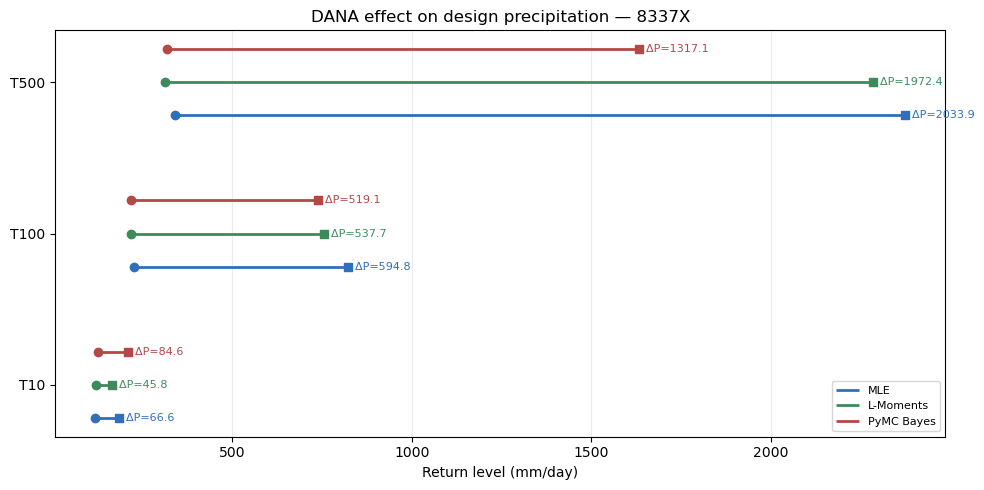

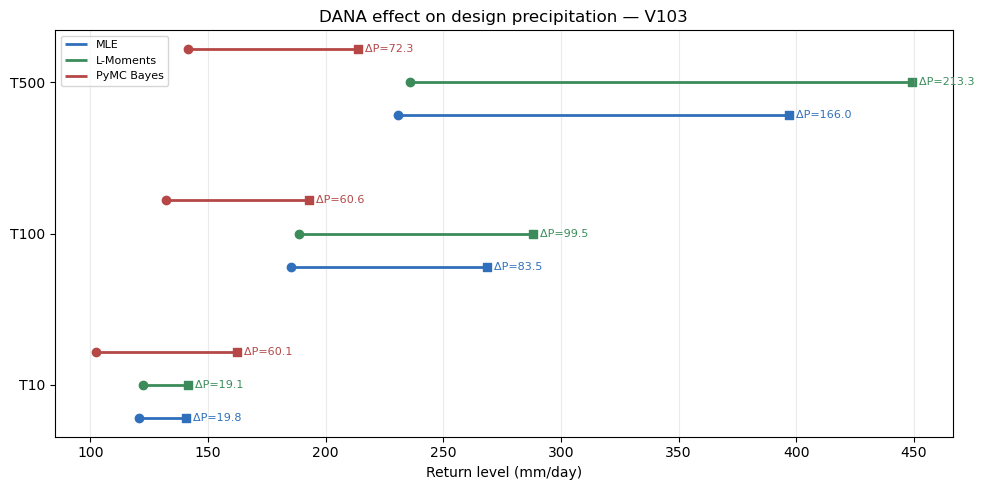

In [31]:
def plot_delta_p_lines(station):
    sub = impact_tables[impact_tables['Station'].eq(station)].copy()
    methods = ['MLE', 'L-Moments', 'PyMC Bayes'] if 'PyMC Bayes' in sub['Method'].unique() else ['MLE', 'L-Moments']
    fig, ax = plt.subplots(figsize=(10, 5))
    y_positions = np.arange(len(T_VALUES))
    offsets = np.linspace(-0.22, 0.22, len(methods))
    colors = {'MLE': '#2f6fbb', 'L-Moments': '#3b8c5a', 'PyMC Bayes': '#b54747'}
    for offset, method in zip(offsets, methods):
        ss = sub[sub['Method'].eq(method)].set_index('T_design').loc[T_VALUES]
        y = y_positions + offset
        ax.hlines(y, ss['P_without_DANA'], ss['P_with_DANA'], color=colors[method], linewidth=2, label=method)
        ax.scatter(ss['P_without_DANA'], y, marker='o', color=colors[method])
        ax.scatter(ss['P_with_DANA'], y, marker='s', color=colors[method])
        for yi, row in zip(y, ss.itertuples()):
            ax.text(max(row.P_without_DANA, row.P_with_DANA), yi, f'  ΔP={row.Delta_P:.1f}', va='center', fontsize=8, color=colors[method])
    ax.set_yticks(y_positions)
    ax.set_yticklabels([f'T{T}' for T in T_VALUES])
    ax.set_xlabel('Return level (mm/day)')
    ax.set_title(f'DANA effect on design precipitation — {station}')
    ax.grid(True, axis='x', alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for station in core_stations:
    plot_delta_p_lines(station)


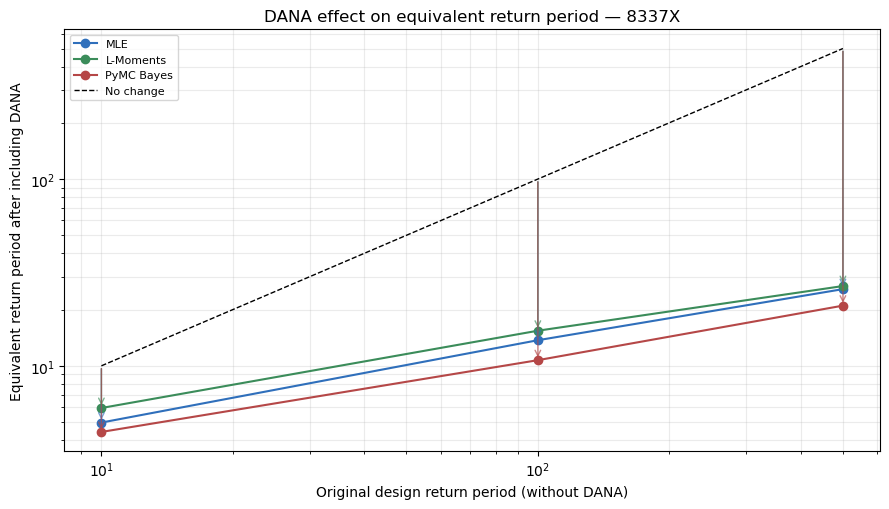

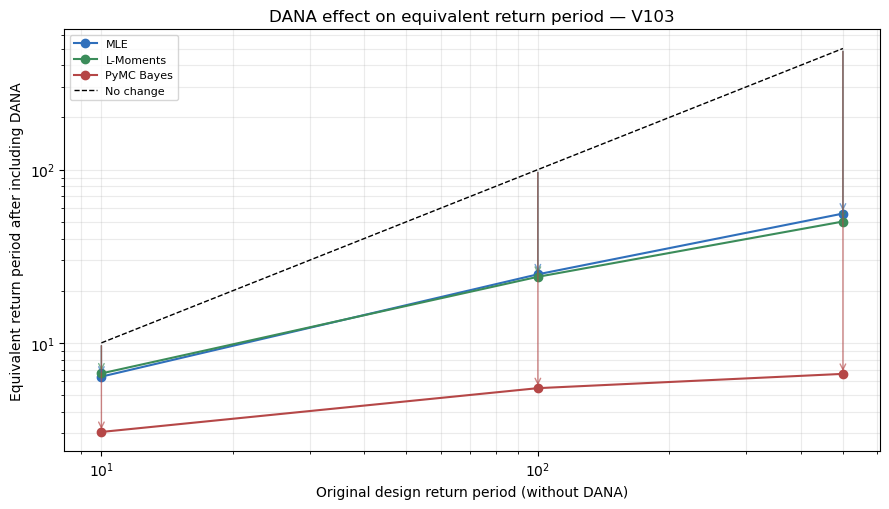

In [32]:
def plot_delta_t_arrows(station):
    sub = impact_tables[impact_tables['Station'].eq(station)].copy()
    methods = ['MLE', 'L-Moments', 'PyMC Bayes'] if 'PyMC Bayes' in sub['Method'].unique() else ['MLE', 'L-Moments']
    colors = {'MLE': '#2f6fbb', 'L-Moments': '#3b8c5a', 'PyMC Bayes': '#b54747'}
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for method in methods:
        ss = sub[sub['Method'].eq(method)].sort_values('T_design')
        ax.plot(ss['T_design'], ss['Equivalent_T_after_DANA'], marker='o', color=colors[method], label=method)
        for row in ss.itertuples():
            ax.annotate('', xy=(row.T_design, row.Equivalent_T_after_DANA), xytext=(row.T_design, row.T_design),
                        arrowprops={'arrowstyle': '->', 'color': colors[method], 'alpha': 0.65})
    ax.plot([min(T_VALUES), max(T_VALUES)], [min(T_VALUES), max(T_VALUES)], color='black', linestyle='--', linewidth=1, label='No change')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Original design return period (without DANA)')
    ax.set_ylabel('Equivalent return period after including DANA')
    ax.set_title(f'DANA effect on equivalent return period — {station}')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for station in core_stations:
    plot_delta_t_arrows(station)


---
### Reading the comparison table

The point estimates above reproduce the archived study values for the core stations because the same annual maxima and GEV fitting methods are used. Regional values are intentionally shown as a comparison, not as an exact reproduction target: this notebook uses the current `pyhydra` index-flood RFA implementation, while the archived Stan-reference tables come from the original paper workflow and its regional pooling/prior choices.


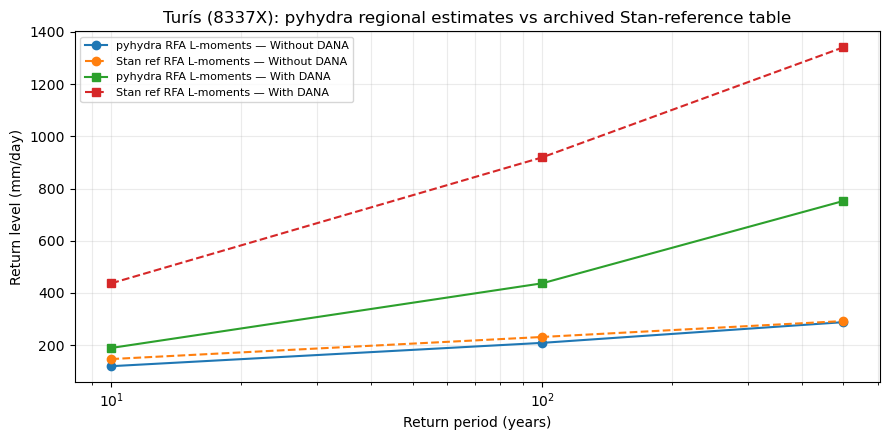

In [33]:
plot_df = comparison[comparison['Station'].eq('8337X')].copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
for scenario, marker in [('Without DANA', 'o'), ('With DANA', 's')]:
    sub = plot_df[plot_df['Scenario'].eq(scenario)]
    ax.plot(sub['Return Period'], sub['pyhydra_L-Moments'], marker=marker, label=f'pyhydra RFA L-moments — {scenario}')
    ax.plot(sub['Return Period'], sub['stan_RFA_L-Moments'], marker=marker, linestyle='--', label=f'Stan ref RFA L-moments — {scenario}')
ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('Return level (mm/day)')
ax.set_title('Turís (8337X): pyhydra regional estimates vs archived Stan-reference table')
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---
## 9. Interpretation

- The daily input data are the same as the real Valencia study source files.
- Point estimates are recomputed with `pyhydra` and reproduce the archived values for the core stations.
- The paper-style standardised RFA workflow is recomputed with `pyhydra`/PyMC when `HYDRA_RUN_PYMC_RFA=1`.
- The hierarchical GEV workflow is implemented with `HierarchicalGEV`/PyMC for the local and general domains; enable it explicitly with `HYDRA_RUN_PYMC_HIER_LOCAL=1` and/or `HYDRA_RUN_PYMC_HIER_GENERAL=1`.
- Stan/PyStan outputs are preserved only as benchmark CSVs under `stan_reference/`.
- Numerical differences between PyMC reruns and the archived Stan tables can arise from sampler length, priors, PyMC/Stan parameterisation and the exact station domain.
